# Cylindrical Shell Theta Baseline

This baseline uses centered cylindrical shell bands.

Each shell is defined by successive outer boundaries:
- `R_i = R_max * (i / n_shells)^(scale_power)`
- `Z_i = Z_max * (i / n_shells)^(scale_power)`

Where scale_power is a user defined value. Default is 1/3

The target is `inside_shell`, meaning an event lies inside shell band `i` and outside shell band `i-1`.


In [1]:
from __future__ import annotations

import json
import yaml
import os
import sys
from pathlib import Path
import numpy as np

import pandas as pd
from IPython.display import Image, display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "PROJECT_EXPERIMENT_GUIDE.md").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root from the current working directory.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)

if str(REPO_ROOT / "src" / "run_cnp") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src" / "run_cnp"))
if str(REPO_ROOT / "src" / "run_mfgp") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src" / "run_mfgp"))
    
from cnp_clean_pipeline import load_runtime_config, predict_cnp, train_cnp
from mfgp_clean_pipeline import run_mfgp_transform_suite

PREP_CONFIG_PATH = REPO_ROOT / "xlzd_shell" / "config" / "pipeline_config.json"
NOTEBOOK_CONFIG_PATH = REPO_ROOT / "xlzd_shell" / "config" / "runtime_notebook_config.json"
CONFIG_PATH = REPO_ROOT / "xlzd_shell" / "config" / "settings_shell_minibatch.yaml"
VALIDATION_CONFIG_PATH = REPO_ROOT / "xlzd_shell" / "config" / "settings_shell_validation_minibatch.yaml"

SEED = 42
STEPS_PER_EPOCH = 5000
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 0.0
REPR_DIM = 32
HIDDEN = 128
DROPOUT = 0.1
MONITOR_EVERY = 5000
MC_SAMPLES = 30
CHUNK_SIZE = 20000
GRID_POINTS = 60
RANDOM_STATE = 42
TARGET_TRANSFORMS = ["linear", "log_hf", "log_lf", "log_both"]


## 1. Choose Notebook Parameters

Edit these values here instead of changing the default JSON config.


In [2]:
NOTEBOOK_PARAMS = {
    "R_max": 1490,
    "Z_max": 1983,
    "n_shells": 100,
    "min_candidate_events": 1,
    "max_events_per_file": None,
    "lf_block_size": 20000,
    "hf_block_size": 100000,
    "validation_block_size": None,
    "negative_shells": 4,
    "scale_power": 1.0/3.0
}

pd.DataFrame({
    "parameter": list(NOTEBOOK_PARAMS.keys()),
    "value": list(NOTEBOOK_PARAMS.values()),
})


,parameter,value
0,R_max,1490.000000
1,Z_max,1983.000000
2,n_shells,100.000000
3,min_candidate_events,1.000000
4,max_events_per_file,NaN
5,lf_block_size,20000.000000
6,hf_block_size,100000.000000
7,validation_block_size,NaN
8,negative_shells,4.000000
9,scale_power,0.333333


## Parameter Guide

- `R_max`: Maximum Radius of Detector. If None dynamically determine from data
- `Z_max`: Maximum Height of Detector measured from center. If None dynamically determine from data
- `n_shells`: Number of shells. Higher value means thinner and more spacial resolution. Lower means thicker and more events per shell
- `min_candidate_events`: Minimum number of events in a shell to consider it a "candidate" for training. Shells below this are ignored for training
- `max_events_per_file`: Maximum number of events to draw from each file read in. Higher means well-supported shells survive. Lower means more shells involved, but noisier.
- `lf_block_size`: Number of events per lf block. High means fewer LF blocks. Lower means more LF files per block
- `hf_block_size`: Same as lf_block_size but for hf data
- `validation_block_size` Same as lf_block_size but for validation data. If None is same as hf
- `scale_power`: Power of the scaling of shells. Cube root means equal volume - default is 1/3

This notebook writes a temporary runtime config but always reuses the same dataset folder:
- `shell_outputs`

So rerunning the prep command overwrites the previous equal-volume shell dataset instead of creating a new dataset tree each time.


## 2. Build A Runtime Config From Those Parameters


In [3]:
# Before doing anything calculate a dynamic R_max, Z_max if one wasnt input
# Nominal detector values are (1490, 1983) for (R_max, Z_max)
if NOTEBOOK_PARAMS["R_max"] is None or NOTEBOOK_PARAMS["Z_max"] is None:
    DATA_PATH = REPO_ROOT / "data"
    r_max = 0.0
    z_min = float("inf")
    z_max_raw = float("-inf")
    for f in DATA_PATH.glob("*.csv"):
        for chunk in pd.read_csv(f, usecols=["x", "y", "z"], chunksize=500000):
            r_chunk = np.sqrt(chunk["x"].to_numpy()**2 + chunk["y"].to_numpy()**2)
            
            r_max = max(r_max, float(np.max(r_chunk)))
            z_min = min(z_min, float(chunk["z"].min()))
            z_max_raw = max(z_max_raw, float(chunk["z"].max()))
    z_center = 0.5 * (z_min + z_max_raw)
    z_max = max(np.abs(z_min-z_center), np.abs(z_max_raw-z_center))

    NOTEBOOK_PARAMS["R_max"] = r_max
    NOTEBOOK_PARAMS["Z_max"] = z_max
    
    print(f"Calculated R_max={r_max:.6g}, Z_max={z_max:.6g}")

prep_config = json.loads(PREP_CONFIG_PATH.read_text())
prep_config["file_load"]["max_rows_per_file"] = NOTEBOOK_PARAMS["max_events_per_file"]
prep_config["shell"]["R_max"] = float(NOTEBOOK_PARAMS["R_max"])
prep_config["shell"]["Z_max"] = float(NOTEBOOK_PARAMS["Z_max"])
prep_config["shell"]["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
prep_config["shell"]["min_candidate_events"] = int(NOTEBOOK_PARAMS["min_candidate_events"])
prep_config["sampling"]["lf_block_size"] = int(NOTEBOOK_PARAMS["lf_block_size"])
prep_config["sampling"]["hf_block_size"] = int(NOTEBOOK_PARAMS["hf_block_size"])
prep_config["sampling"]["validation_block_size"] = NOTEBOOK_PARAMS["validation_block_size"]
prep_config["shell"]["scale_power"] = float(NOTEBOOK_PARAMS["scale_power"])

NOTEBOOK_CONFIG_PATH.write_text(json.dumps(prep_config, indent=2))

# Make sure the yamls have the correct shell geometry
for yaml_path in [CONFIG_PATH, VALIDATION_CONFIG_PATH]:
    yaml_config = yaml.safe_load(yaml_path.read_text())
    sim = yaml_config["simulation_settings"]

    sim["R_max"] = float(NOTEBOOK_PARAMS["R_max"])
    sim["Z_max"] = float(NOTEBOOK_PARAMS["Z_max"])
    sim["n_shells"] = int(NOTEBOOK_PARAMS["n_shells"])
    sim["scale_power"] = float(NOTEBOOK_PARAMS["scale_power"])

    yaml_path.write_text(
        yaml.safe_dump(
            yaml_config,
            sort_keys=False,
        )
    )

runtime = load_runtime_config(CONFIG_PATH, seed=SEED)
validation_runtime = load_runtime_config(VALIDATION_CONFIG_PATH, seed=SEED)

summary = pd.DataFrame({
    "field": [
        "version",
        "R_max",
        "Z_max",
        "n_shells",
        "min_candidate_events",
        "lf_block_size",
        "hf_block_size",
        "validation_block_size",
        "theta_headers",
        "phi_headers",
        "target_headers",
        "scale_power",
    ],
    "value": [
        runtime.version,
        prep_config["shell"].get("R_max"),
        prep_config["shell"].get("Z_max"),
        prep_config["shell"].get("n_shells"),
        prep_config["shell"].get("min_candidate_events"),
        prep_config["sampling"].get("lf_block_size"),
        prep_config["sampling"].get("hf_block_size"),
        prep_config["sampling"].get("validation_block_size"),
        ", ".join(runtime.theta_headers),
        ", ".join(runtime.phi_headers),
        ", ".join(runtime.target_headers),
        prep_config["shell"].get("scale_power"),
    ],
})
summary


,field,value
0,version,xlzd_shell_v1_minibatch
1,R_max,1490.0
2,Z_max,1983.0
3,n_shells,100
4,min_candidate_events,1
5,lf_block_size,20000
6,hf_block_size,100000
7,validation_block_size,None
8,theta_headers,"R_shell, Z_shell"
9,phi_headers,"s_r, s_z_from_center"


## 3. Prepare The Shell Dataset

Run this from the repo root before training if the dataset has not been built yet.

If you want more inner-shell candidates, lower `min_candidate_events` first. If you want fewer repeated shell assignments, increase `lf_block_size`.

This prep step now clears and rebuilds `shell_outputs`, so changing notebook parameters refreshes the same dataset instead of leaving old files behind.


In [4]:
import subprocess

cmd = [
    sys.executable,
    "xlzd_shell/prepare_shell_data.py",
    "--config",
    str(NOTEBOOK_CONFIG_PATH.relative_to(REPO_ROOT)),
]

print("$ " + " ".join(cmd))
subprocess.run(cmd, cwd=REPO_ROOT, check=True)

$ /home/liuser/miniconda3/bin/python xlzd_shell/prepare_shell_data.py --config xlzd_shell/config/runtime_notebook_config.json

[20:27:08] Loading and normalizing raw event files


Loading event files: 100%|██████████| 7/7 [00:04<00:00,  1.74it/s]


[done in 4.06s] Loaded 7 files

[20:27:12] Computing detector coordinates
[done in 0.14s] Using z_center=1982.48, R_max=1490, Z_max: 1983

[20:27:12] Splitting raw events into disjoint LF/HF/validation pools
[done in 1.08s] Pool split complete

[20:27:13] Splitting pools into equal-size event blocks
[done in 0.00s] Pool block split complete

[20:27:13] Building full shell table
[warn] Some shell classes have low support, but they are kept for categorical CE because class IDs must remain fixed
[done in 0.07s] Built full shell table with 100 shell classes

[20:27:13] Clearing existing dataset directory: shell_outputs
[done in 0.32s] Removed previous shell dataset

[20:27:14] Writing LF Training event-class H5 blocks
[done in 0.77s] 53 LF Training blocks written

[20:27:15] Writing HF Training event-class H5 blocks
[done in 0.87s] 21 HF Training blocks written

[20:27:15] Writing HF Validation event-class H5 blocks
[done in 0.88s] 21 HF Validation blocks written

[20:27:16] Writing pool t

CompletedProcess(args=['/home/liuser/miniconda3/bin/python', 'xlzd_shell/prepare_shell_data.py', '--config', 'xlzd_shell/config/runtime_notebook_config.json'], returncode=0)

## 4. Train The CNP


[warn] Shell classes with zero training examples: [0, 1, 2, 3, 4, 5, 6, 9, 10, 11, 13]

[class weights]
min count: 1
max count: 147921
min weight: 0.0126
max weight: 12.5815

[info] Random mini-batch mode is enabled. Each epoch uses 5000 sampled steps.


Epoch 1/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

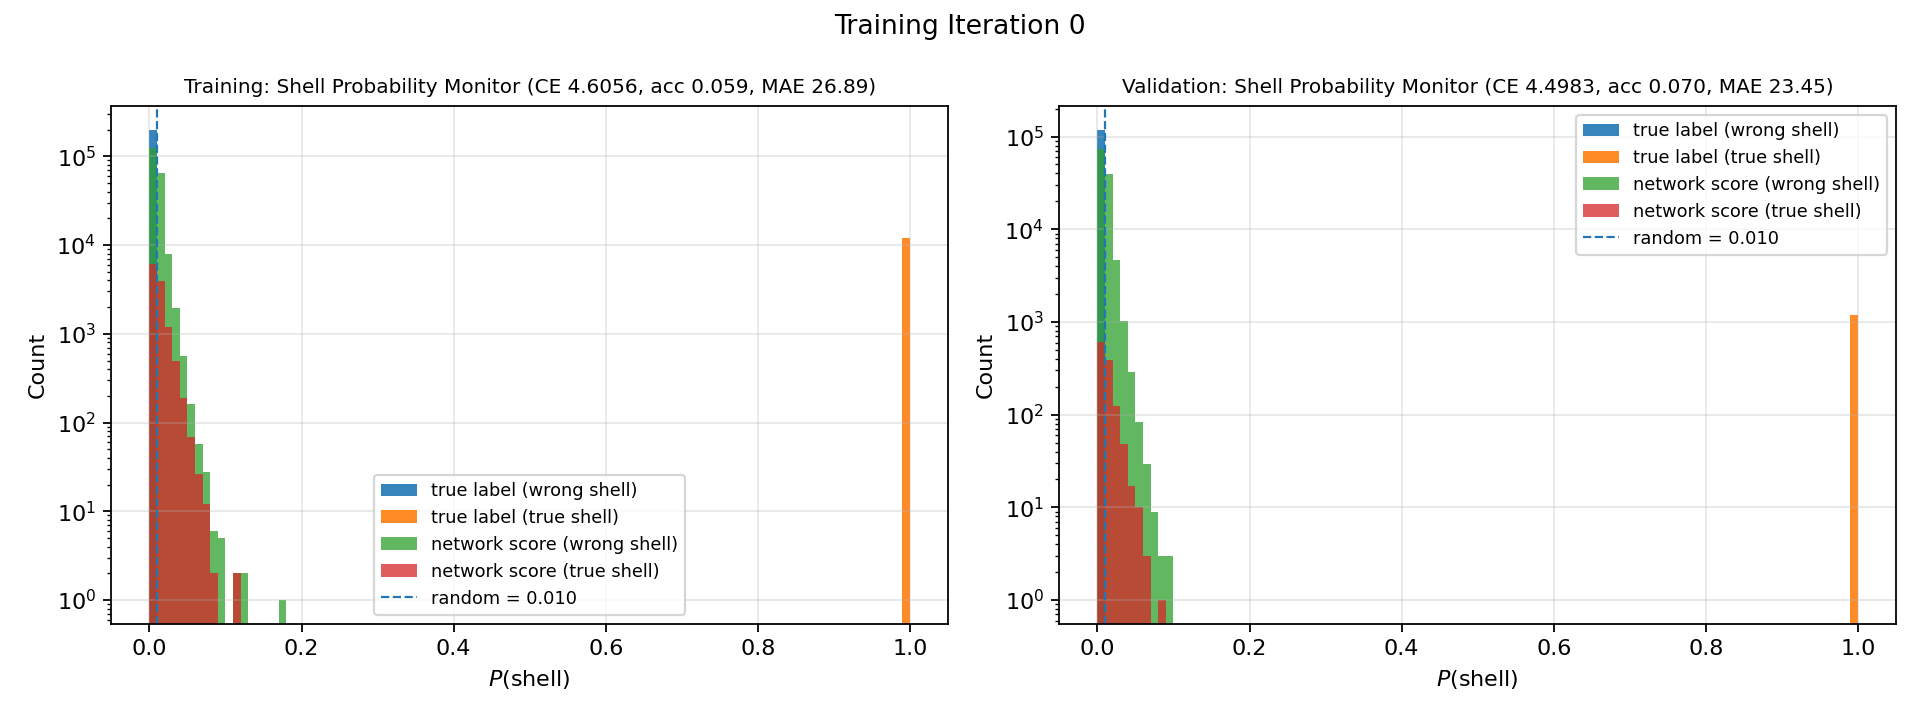

Epoch 2/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

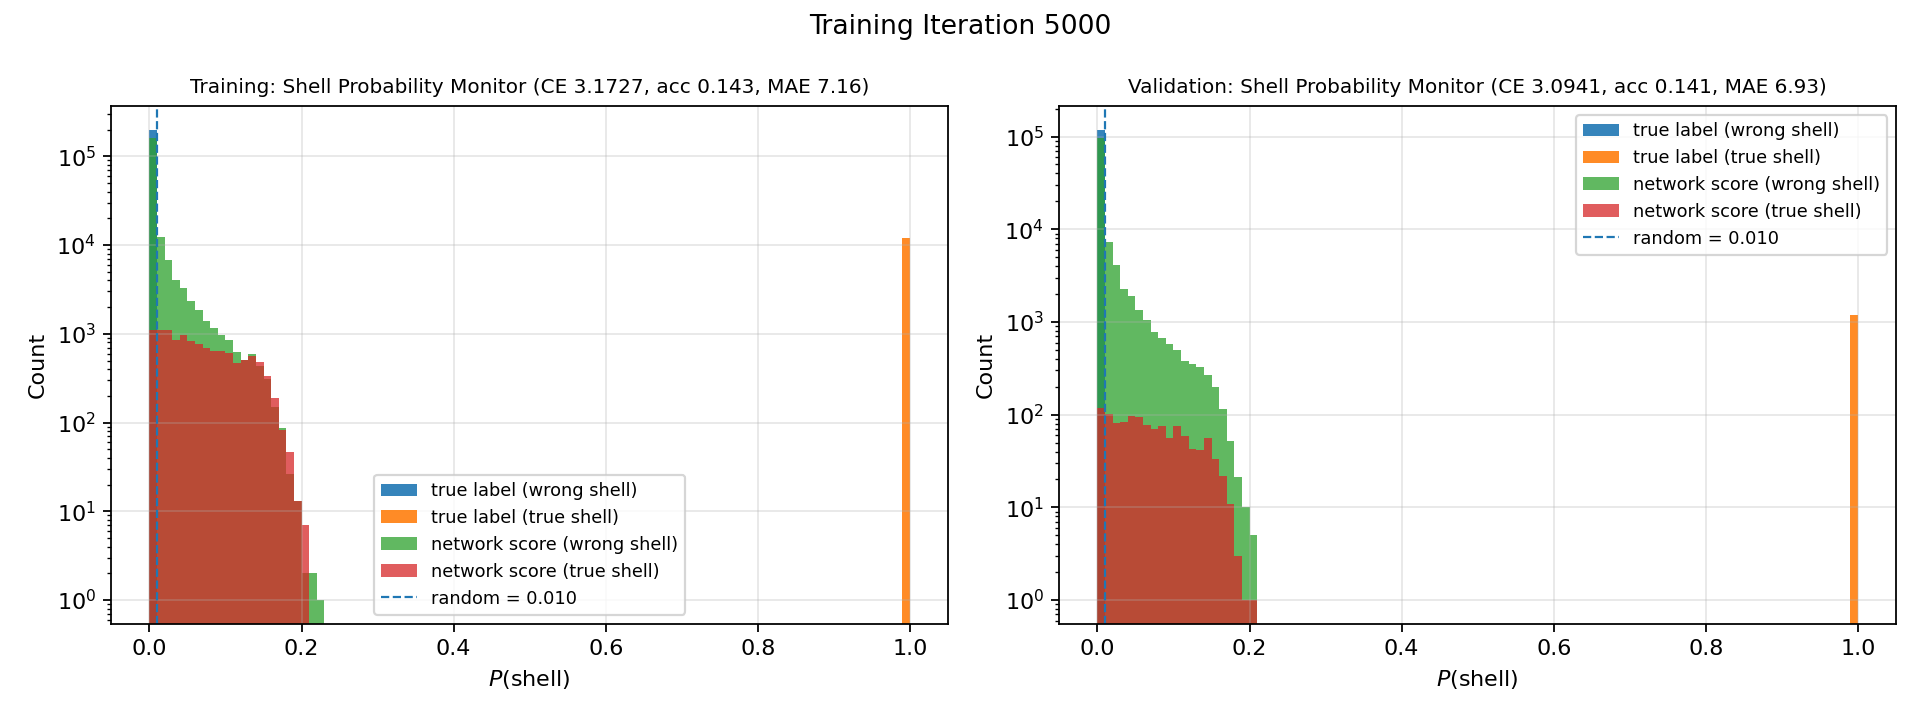

Epoch 3/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

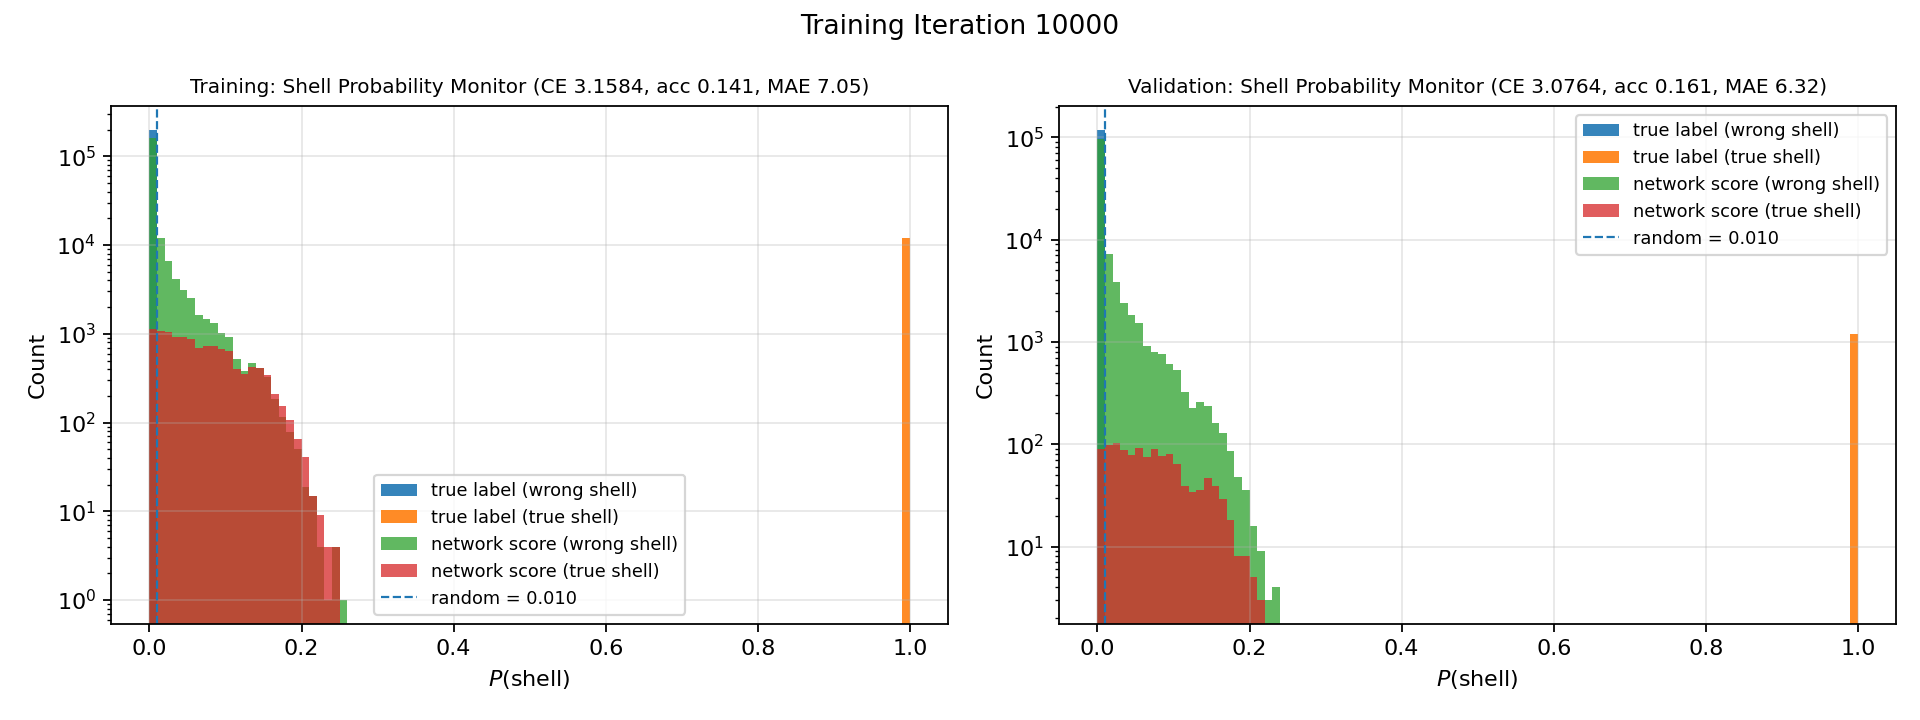

Epoch 4/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

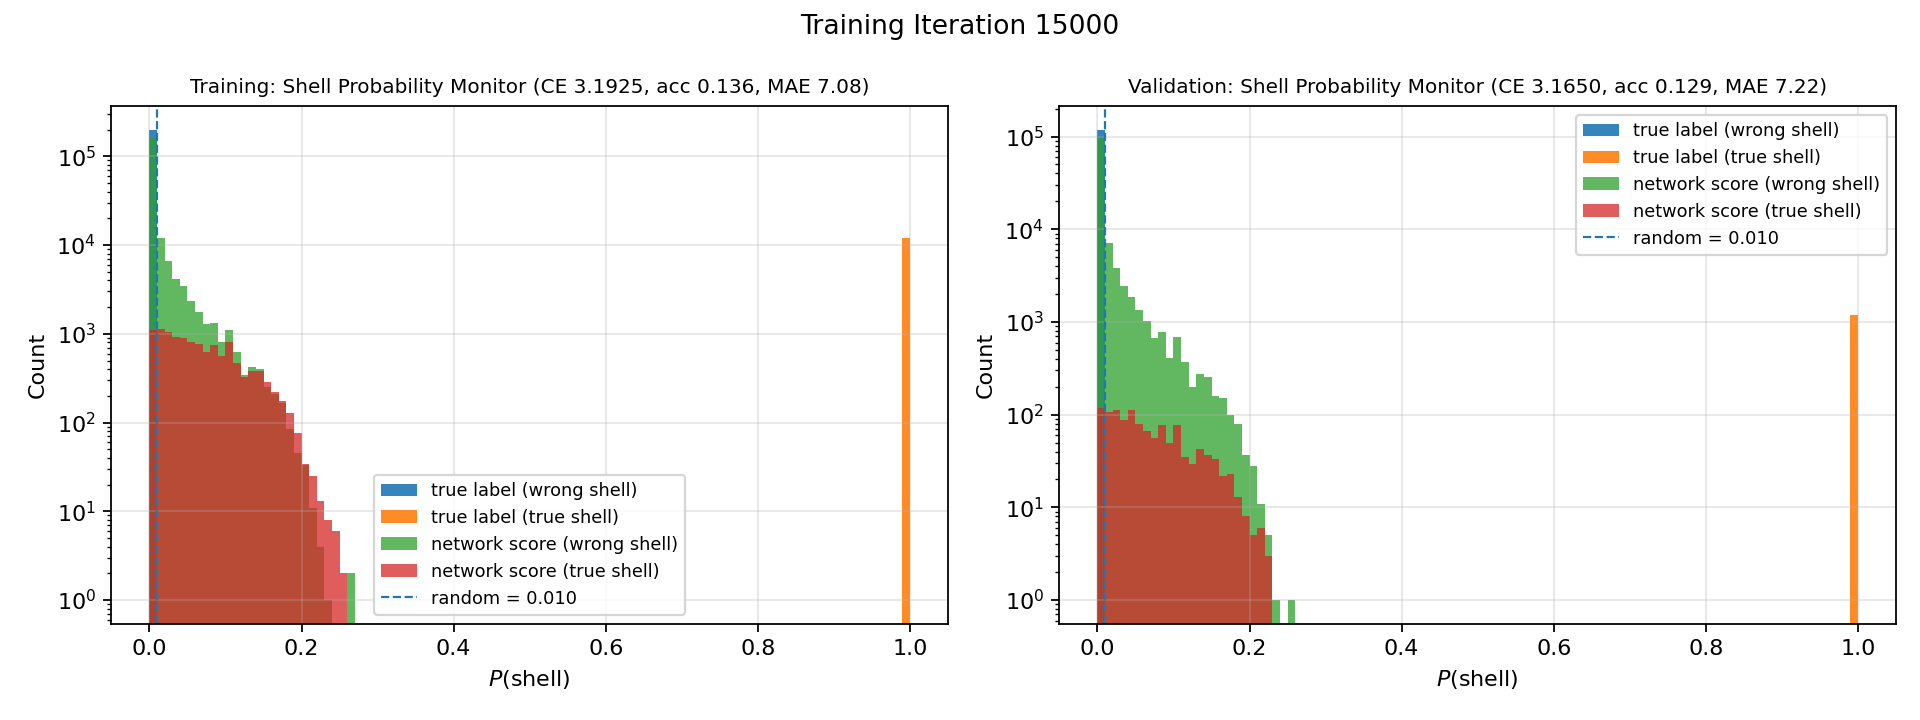

Epoch 5/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

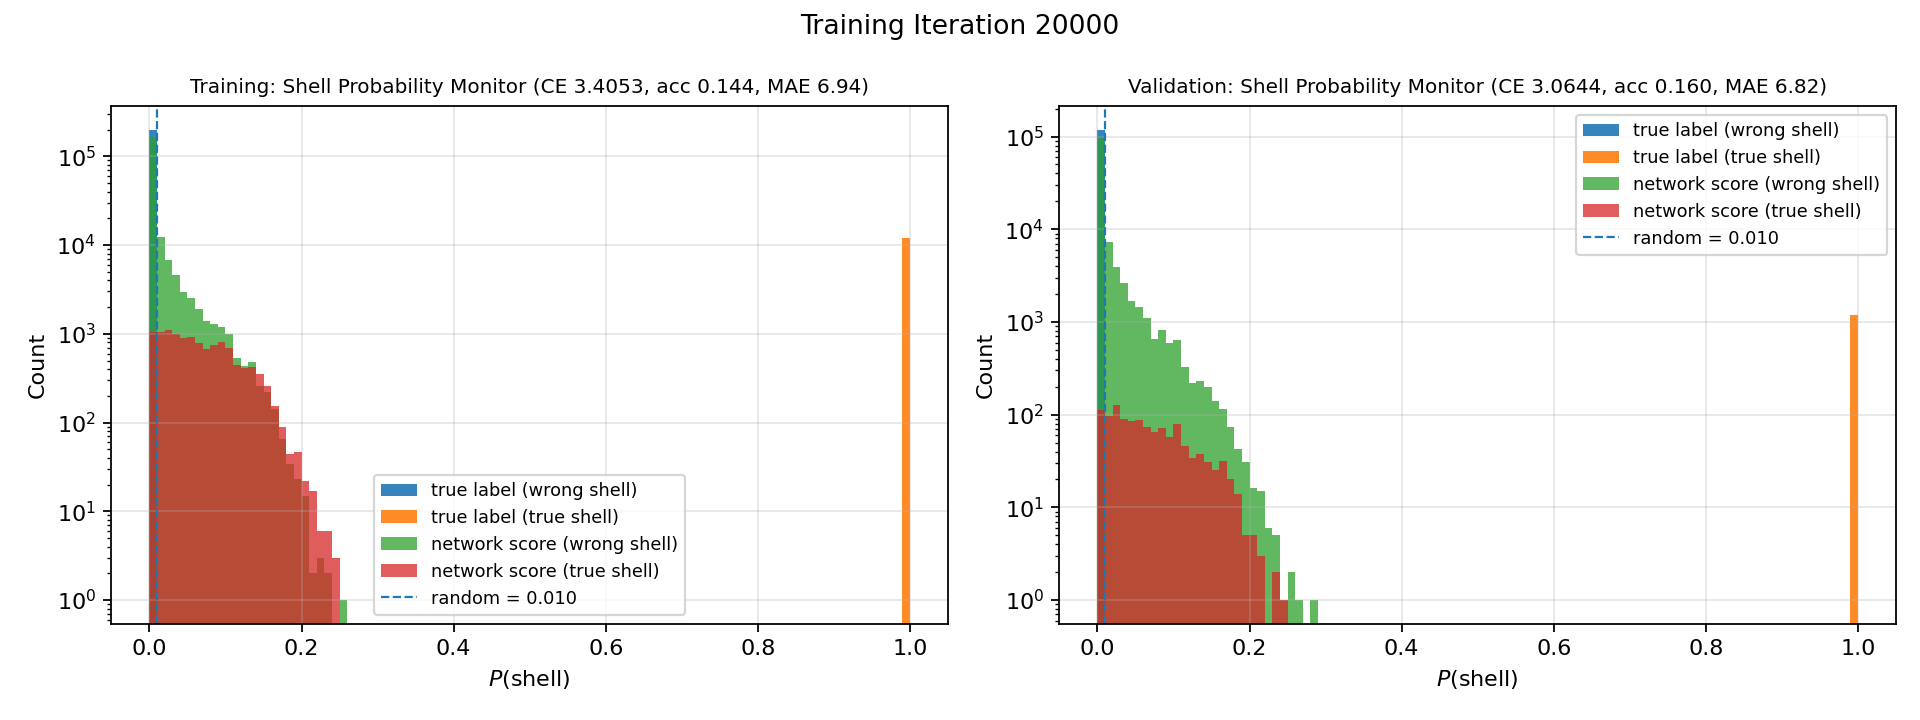

Epoch 6/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

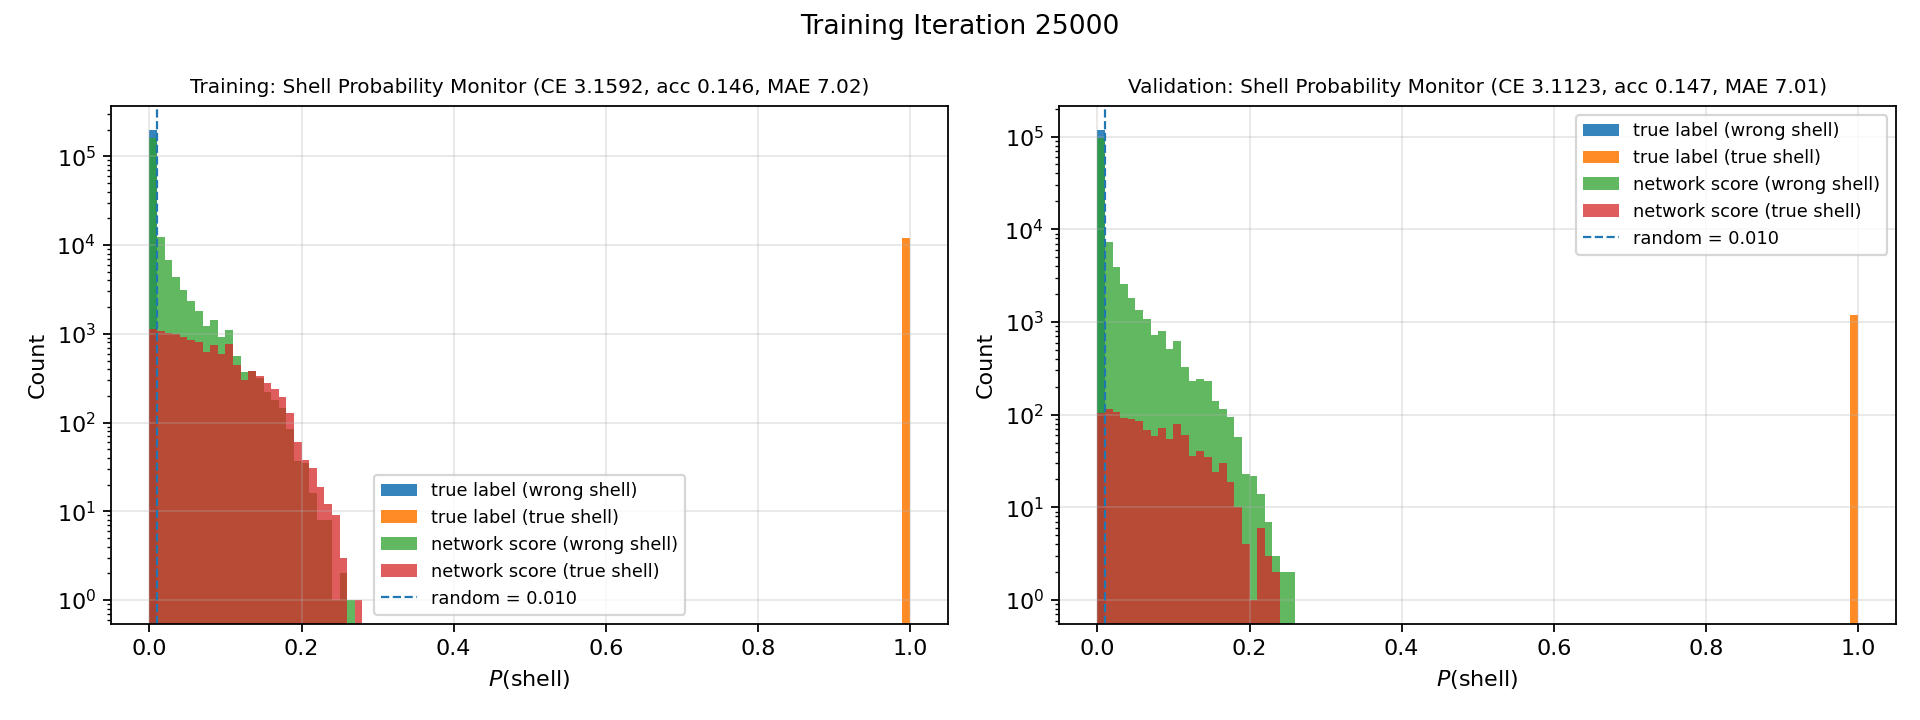

Epoch 7/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

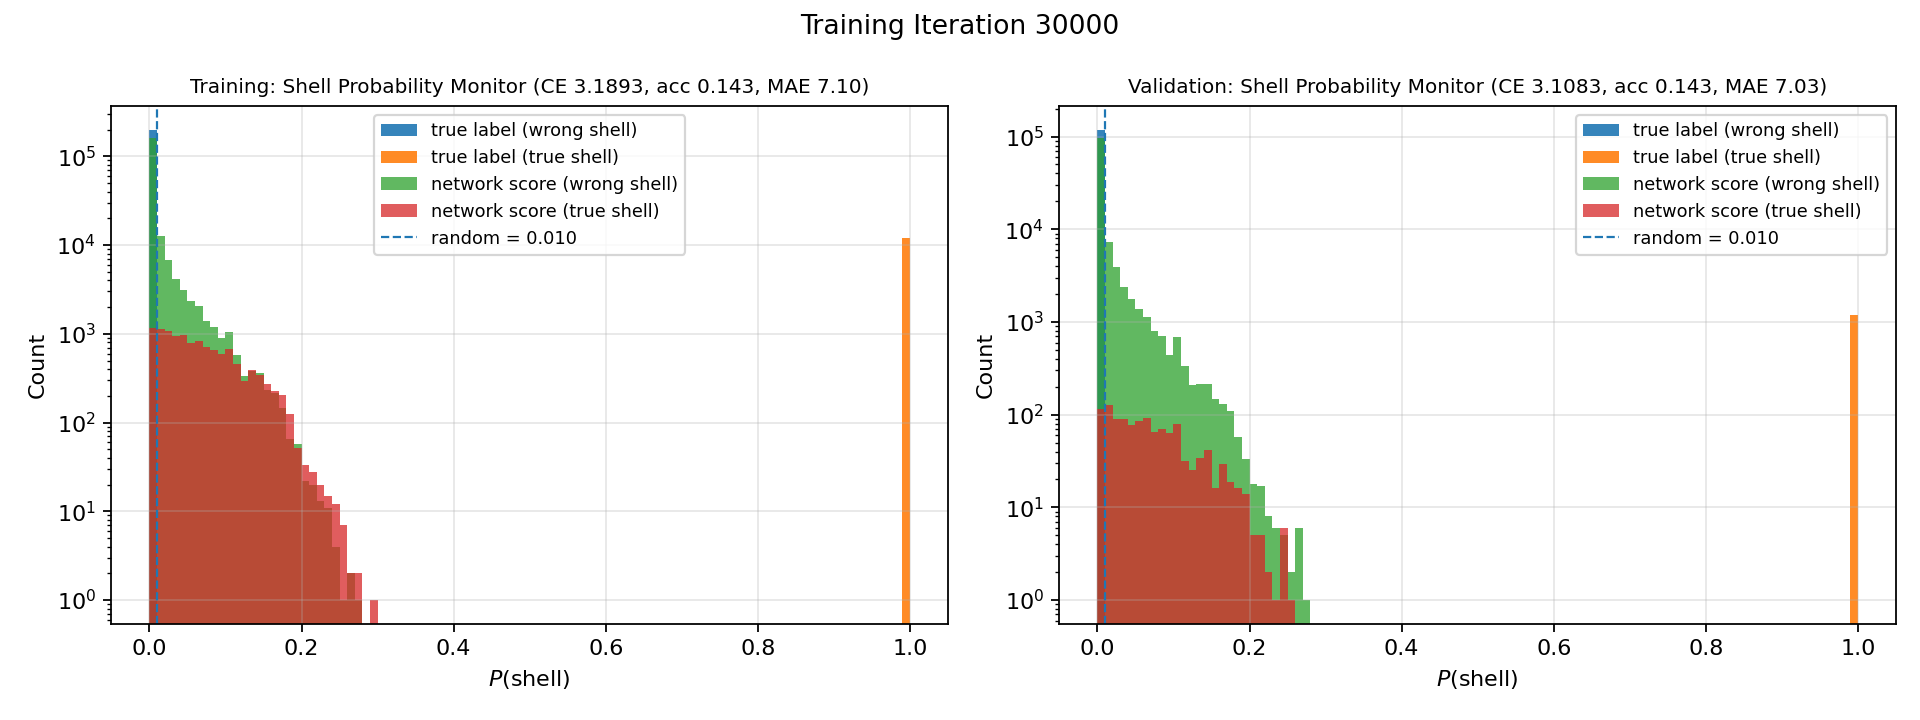

Epoch 8/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

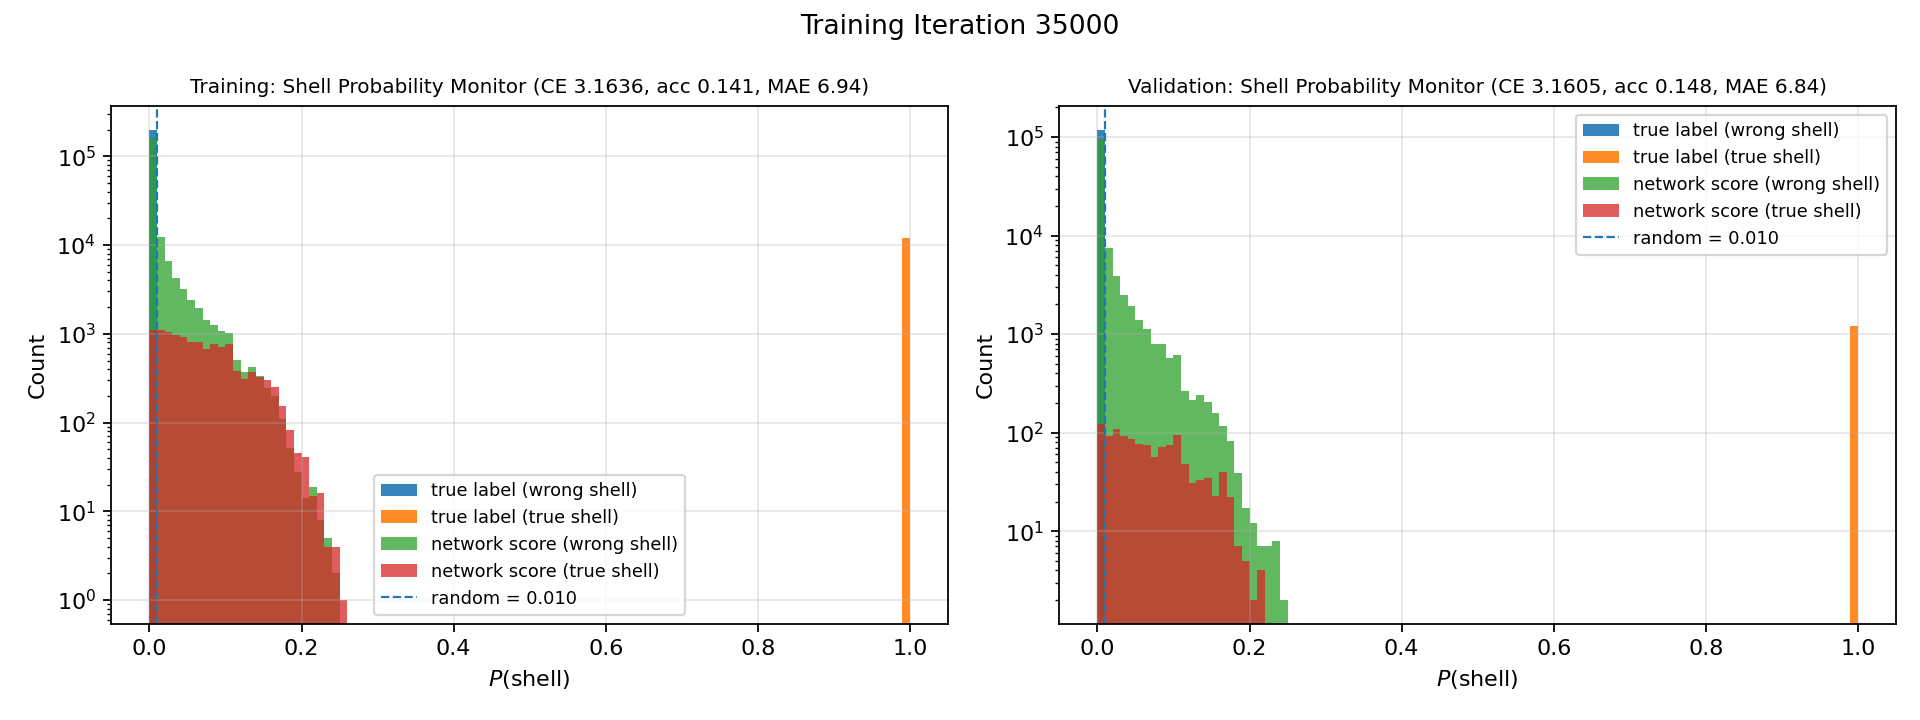

Epoch 9/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

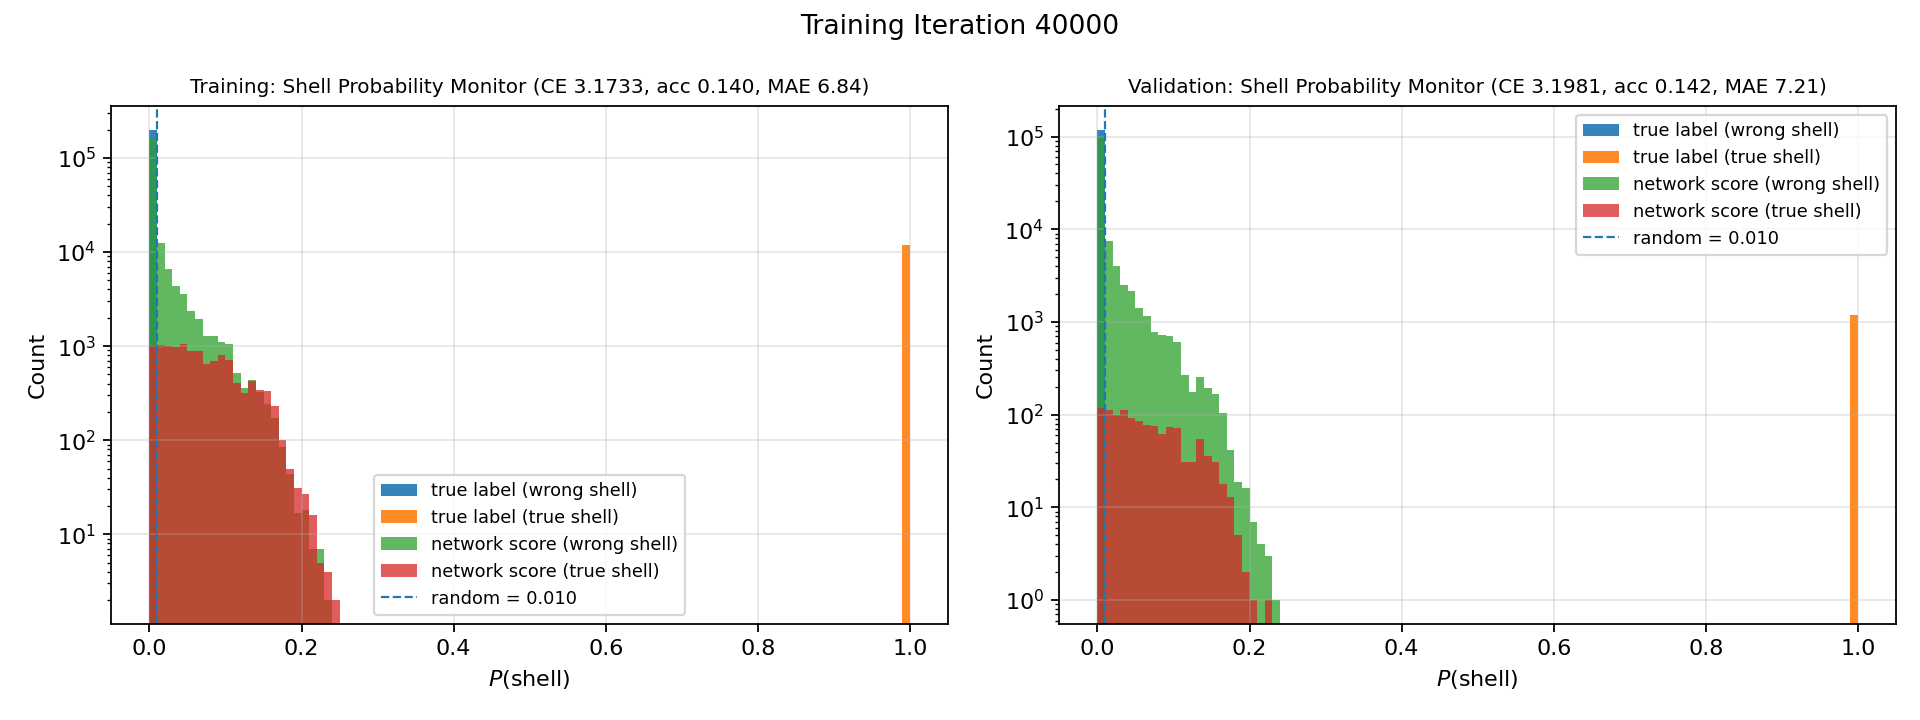

Epoch 10/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

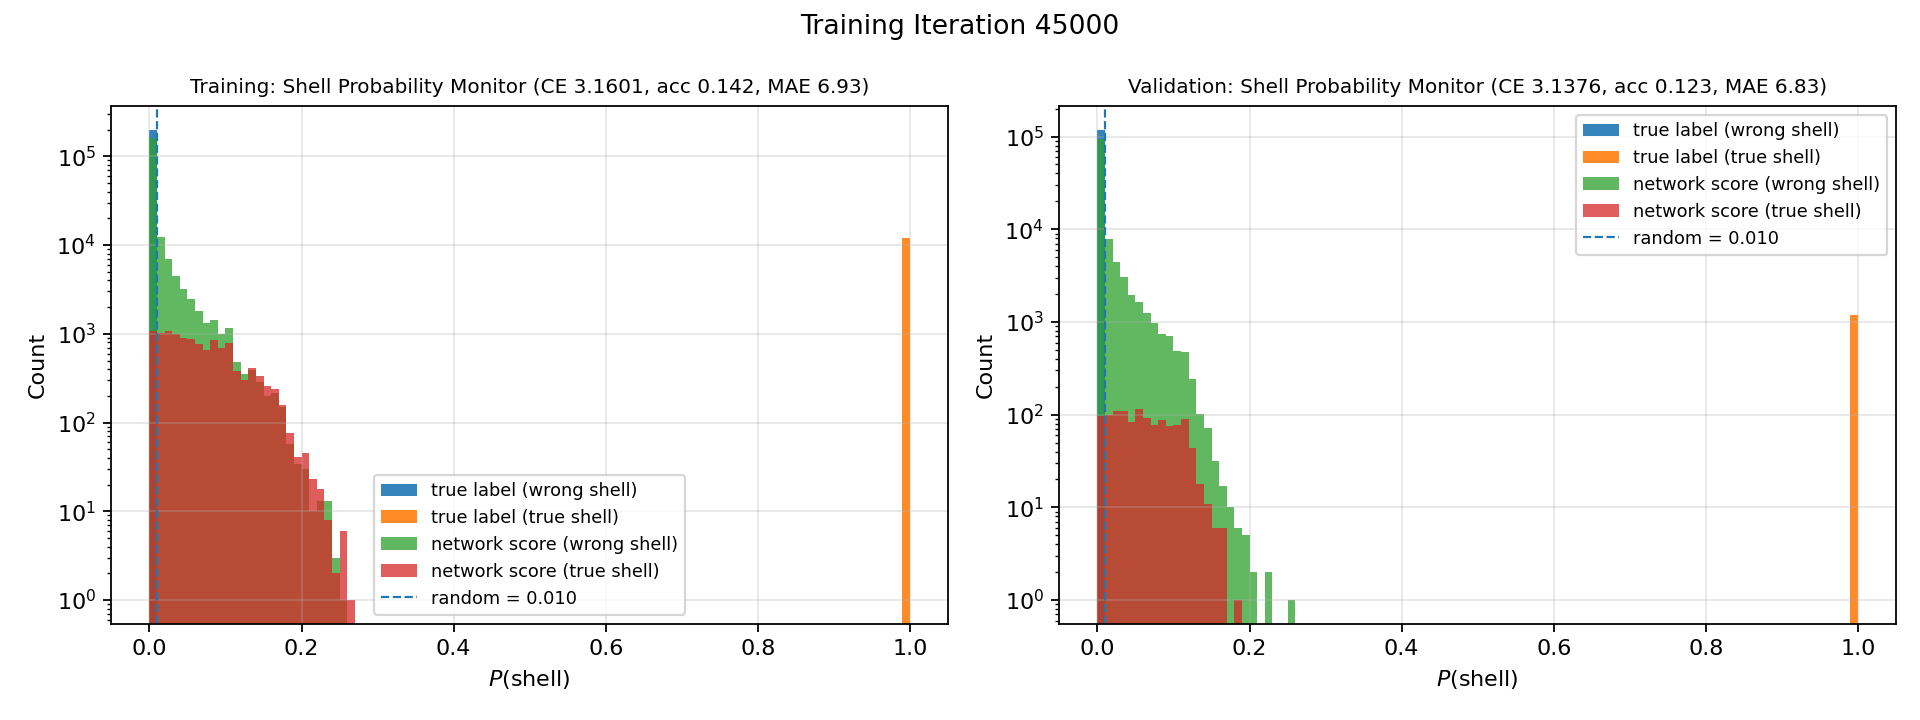

Epoch 11/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

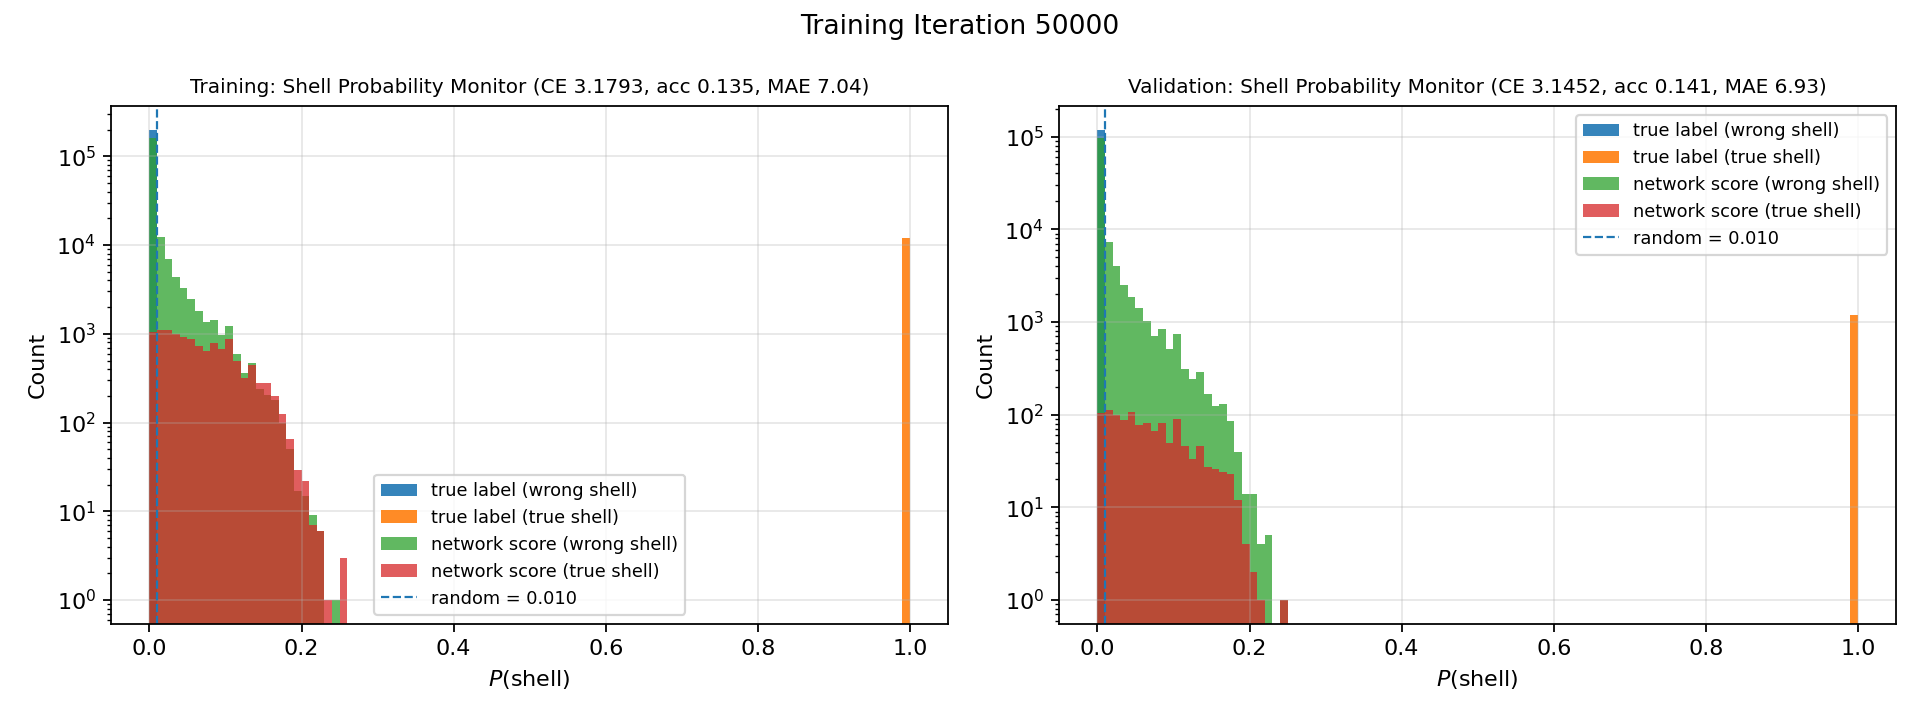

Epoch 12/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

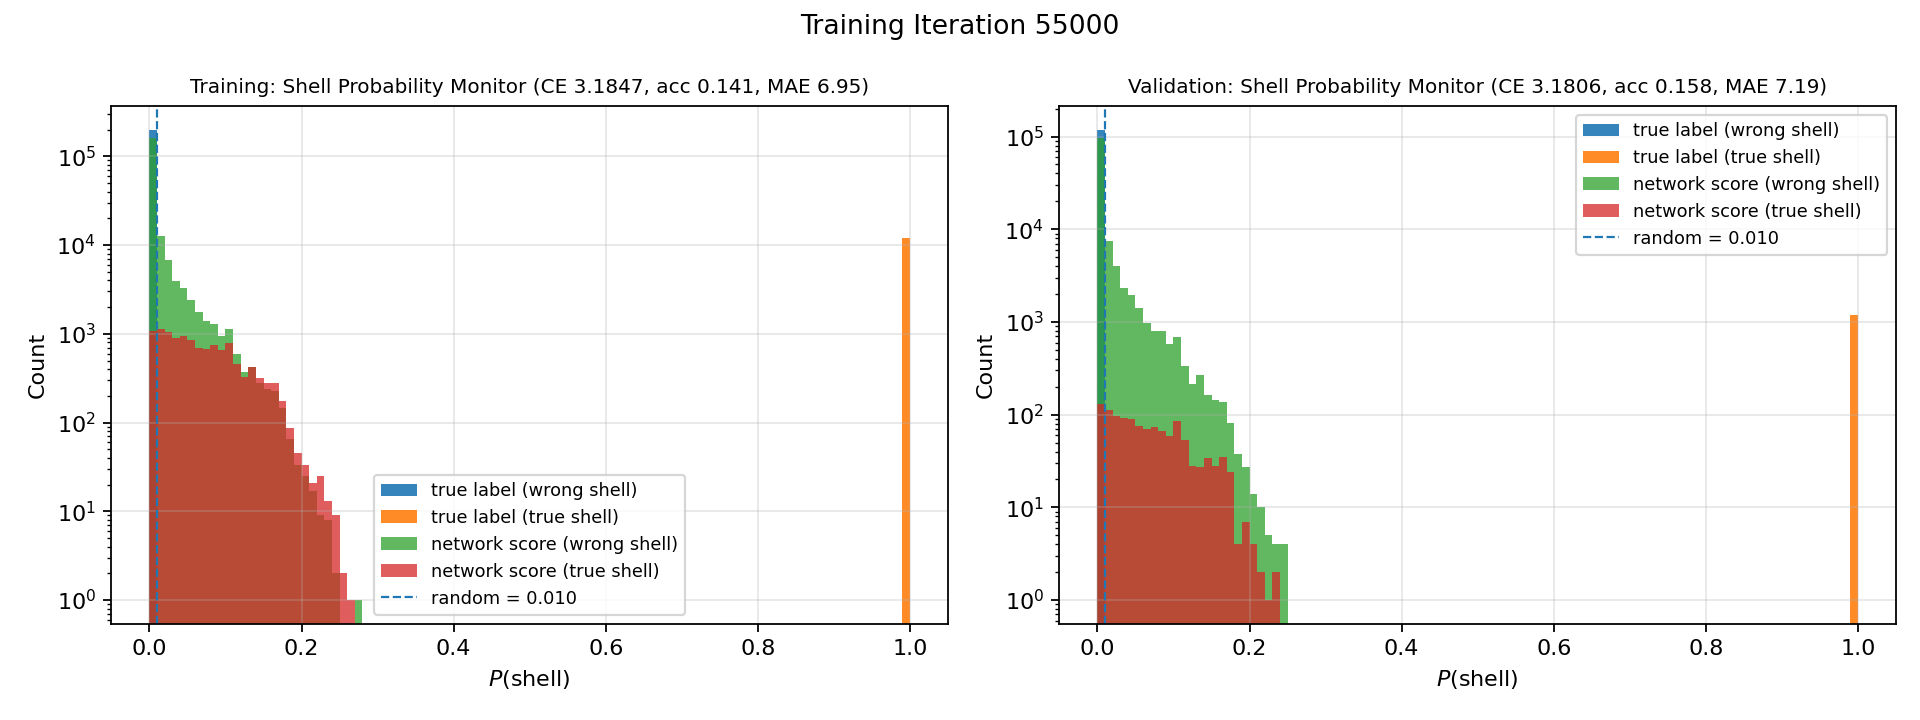

Epoch 13/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

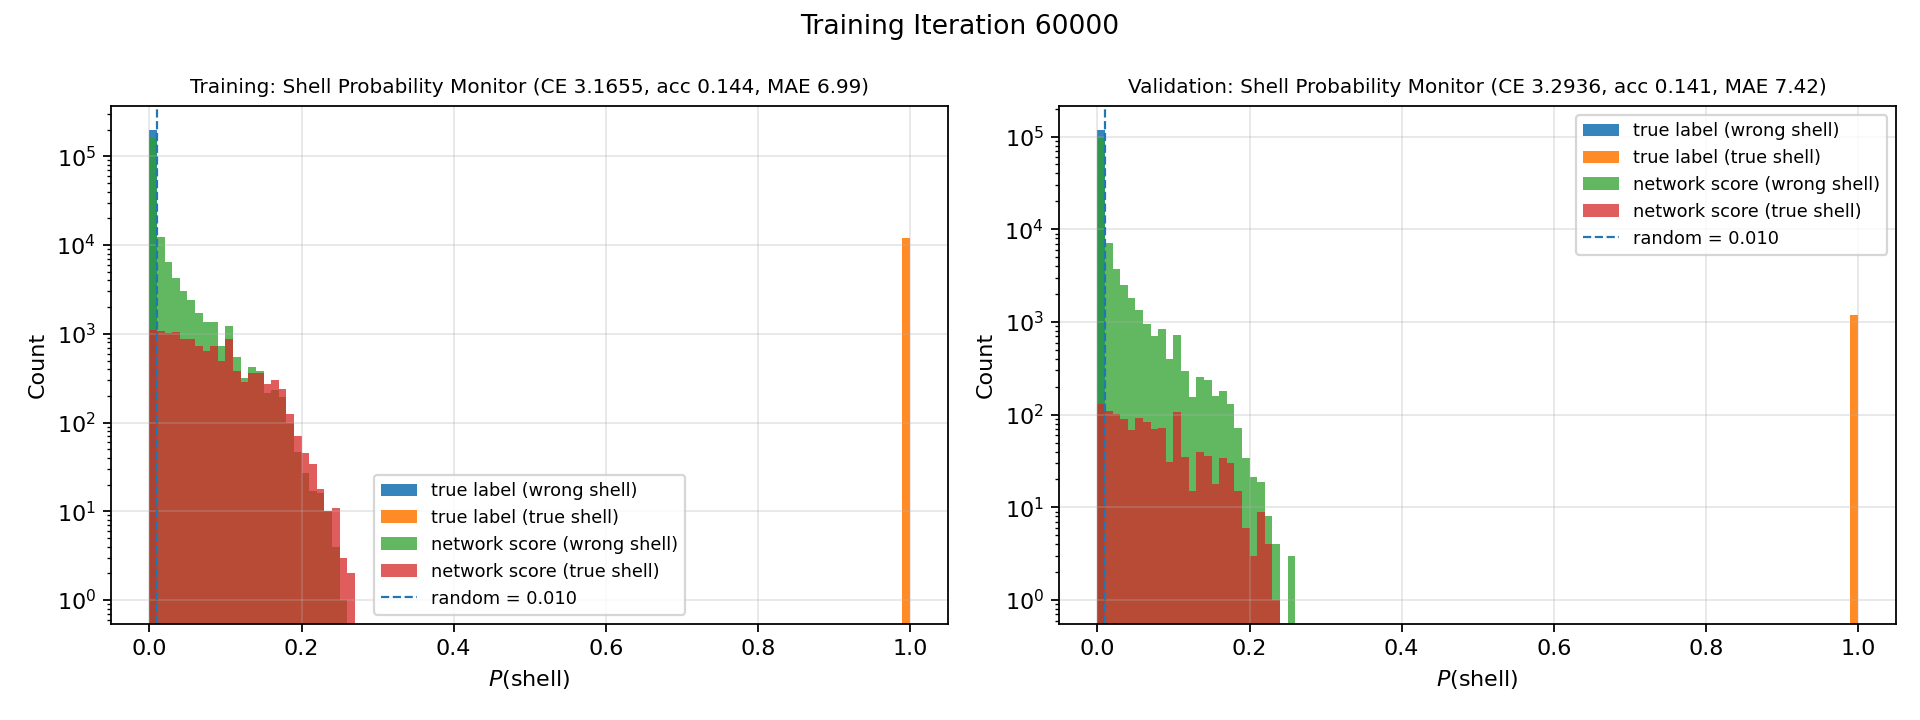

Epoch 14/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

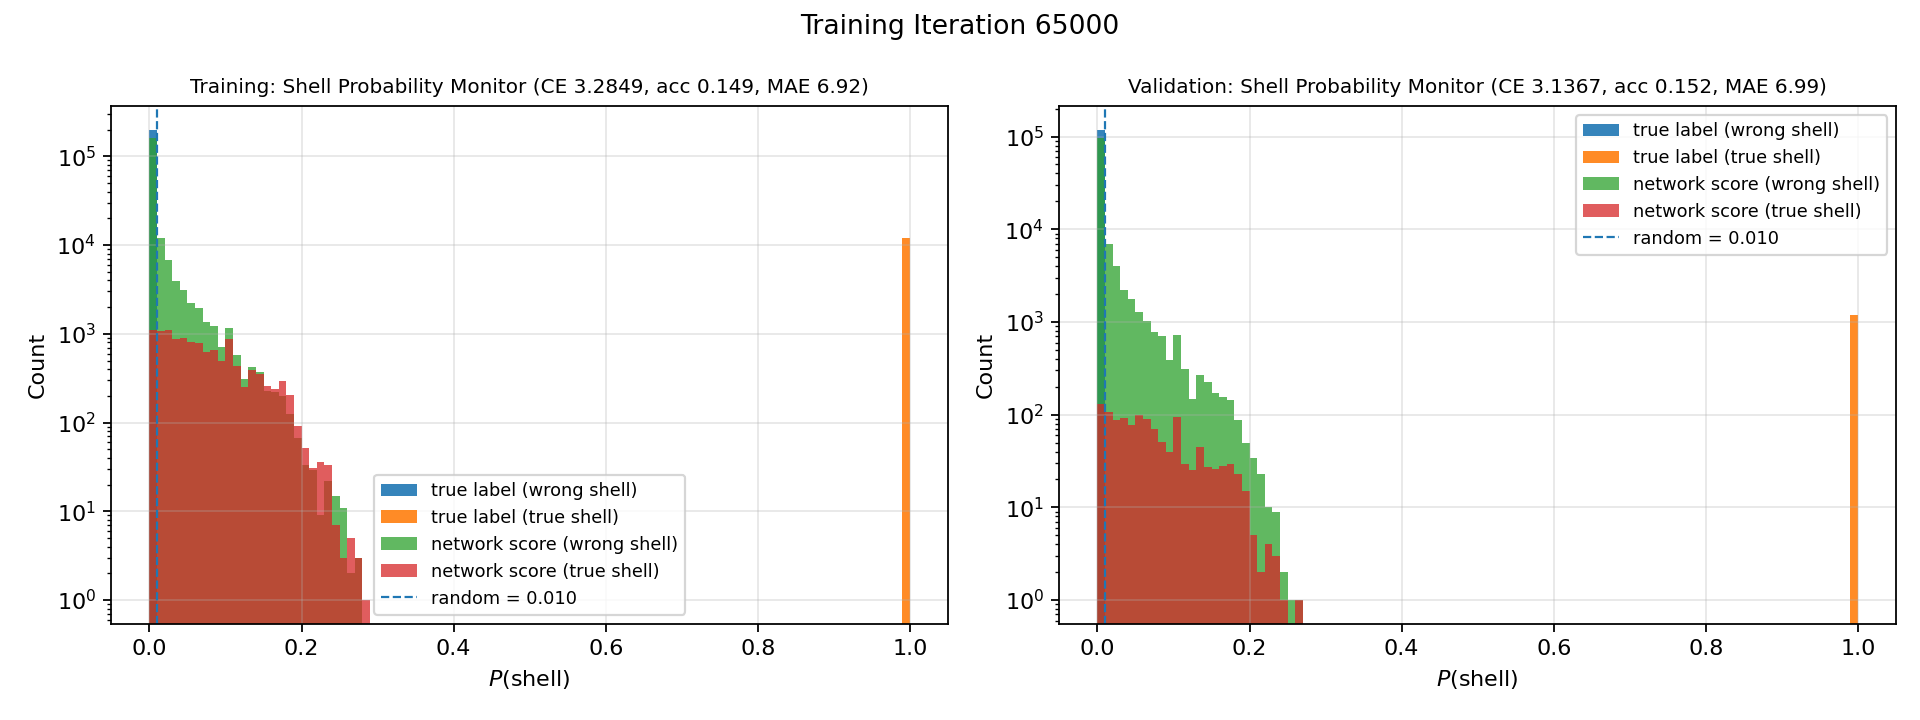

Epoch 15/15:   0%|          | 0/5000 [00:00<?, ?batch/s]

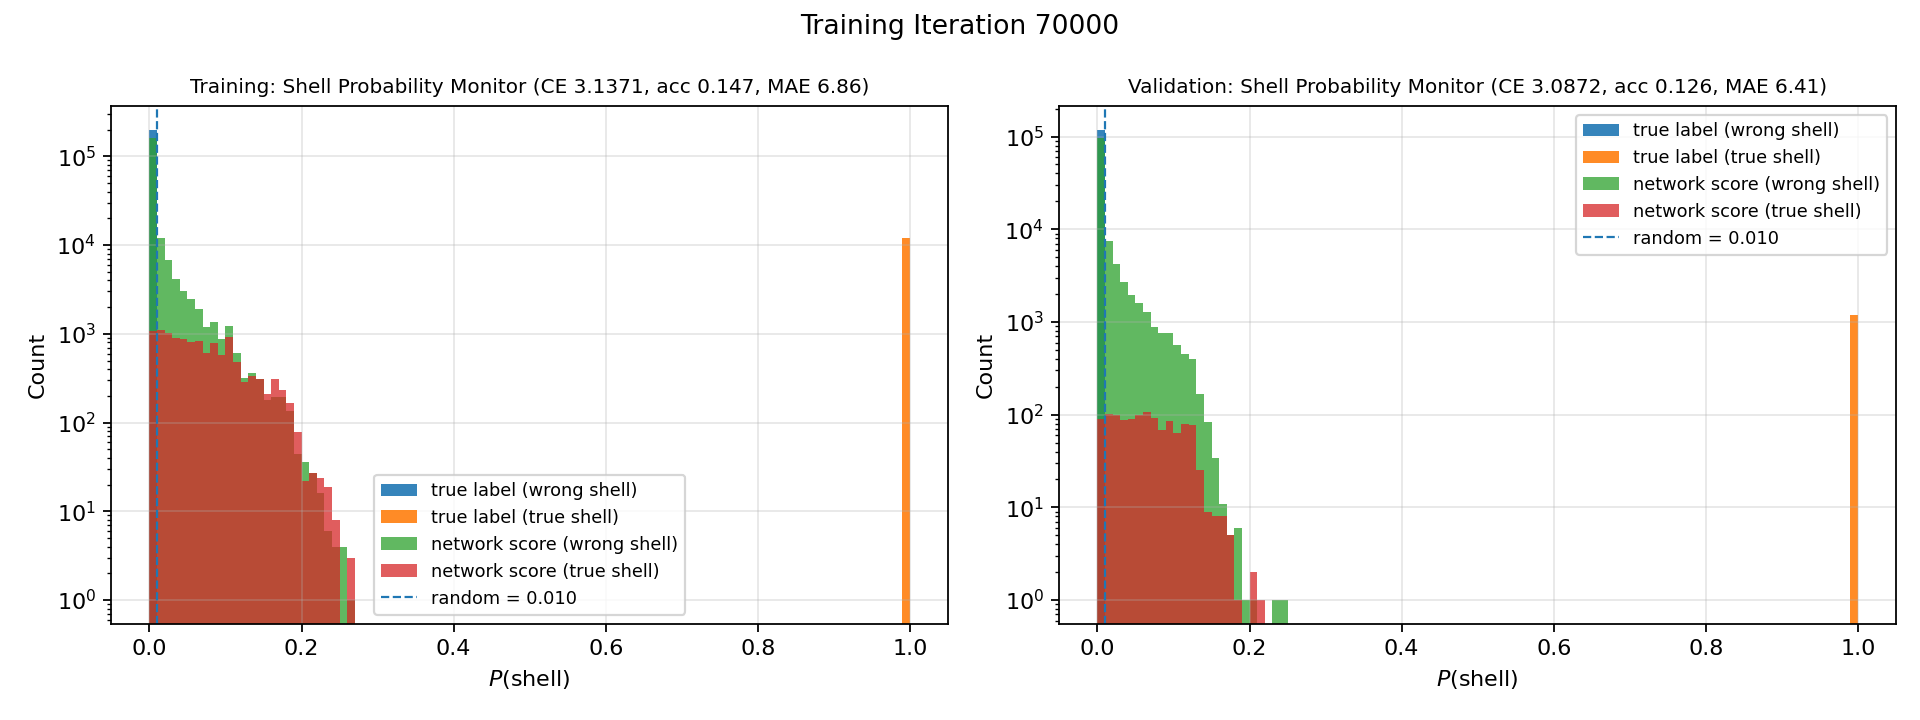

,artifact,path
0,model_path,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
1,history_csv,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
2,history_plot,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
3,sample_plot,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...


In [5]:
train_result = train_cnp(
    runtime,
    steps_per_epoch=STEPS_PER_EPOCH,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    repr_dim=REPR_DIM,
    hidden=HIDDEN,
    dropout=DROPOUT,
    monitor_every=MONITOR_EVERY,
    show_monitor_plots=True,
)

pd.DataFrame({
    "artifact": ["model_path", "history_csv", "history_plot", "sample_plot"],
    "path": [
        str(train_result.model_path),
        str(train_result.history_csv),
        str(train_result.history_plot),
        str(train_result.sample_plot),
    ],
})


## 5. Predict On Training LF/HF And Validation HF


In [6]:
train_prediction = predict_cnp(
    runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
    output_suffix="train"
)

validation_prediction = predict_cnp(
    validation_runtime,
    model_path=train_result.model_path,
    mc_samples=MC_SAMPLES,
    chunk_size=CHUNK_SIZE,
    output_suffix="validation"
)

pd.DataFrame({
    "artifact": [
        "train_all",
        "train_best",
        "train_mfgp",
        "validation_all",
        "validation_best",
        "validation_mfgp",
    ],
    "path": [
        str(train_prediction.all_path),
        str(train_prediction.best_path),
        str(train_prediction.mfgp_path),
        str(validation_prediction.all_path),
        str(validation_prediction.best_path),
        str(validation_prediction.mfgp_path),
    ],
})



Starting CNP prediction


TRAIN-LF:   0%|          | 0/53 [00:00<?, ?block/s]

TRAIN-HF:   0%|          | 0/21 [00:00<?, ?block/s]


MFGP CSV:       /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_train_15epochs.csv
All-shell CSV:  /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_train_15epochs_all_shells.csv
Best-shell CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_train_15epochs_best_shell.csv

Starting CNP prediction


VAL-HF:   0%|          | 0/21 [00:00<?, ?block/s]


MFGP CSV:       /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs.csv
All-shell CSV:  /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs_all_shells.csv
Best-shell CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs_best_shell.csv


,artifact,path
0,train_all,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
1,train_best,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
2,train_mfgp,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
3,validation_all,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
4,validation_best,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...
5,validation_mfgp,/home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlz...


## 6. Inspect CNP Outputs


(<Figure size 1200x800 with 2 Axes>,
 [<Axes: title={'center': 'Predicted Shell Distribution'}, xlabel='Shell Number', ylabel='Count'>,
  <Axes: title={'center': 'True Shell Distribution'}, xlabel='Shell Number', ylabel='Count'>])

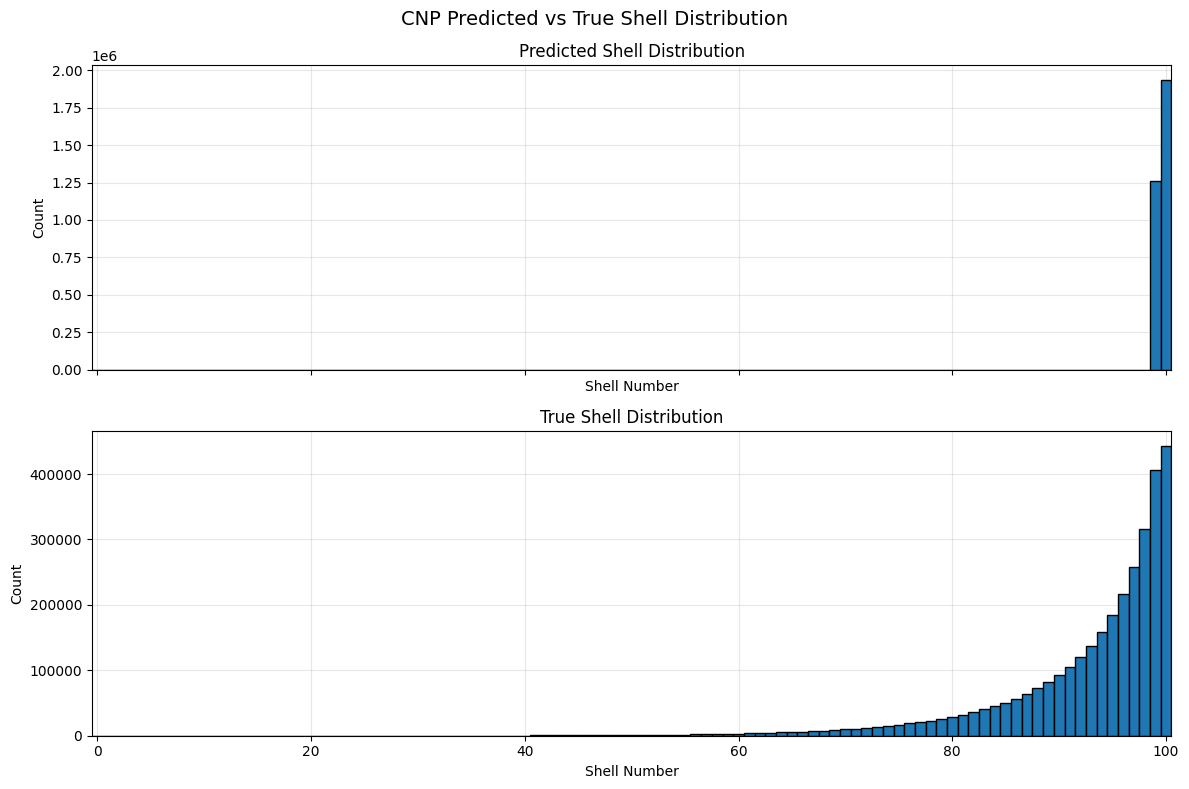

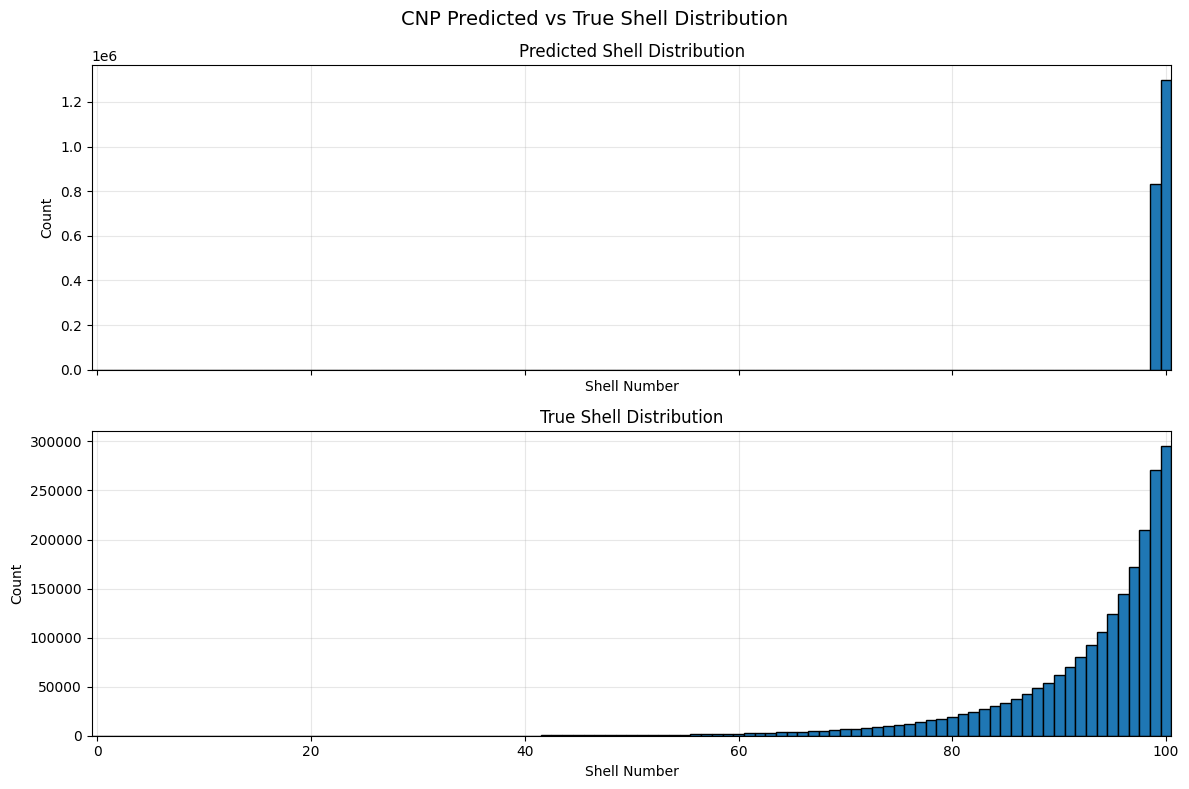

In [7]:
from xlzd_shell.visualize import plot_cnp_pred_shell_occupancy

plot_cnp_pred_shell_occupancy(train_prediction)
plot_cnp_pred_shell_occupancy(validation_prediction)

## 7. Fit The MF-GP Transform Suite


In [8]:
cnp_train_csv = train_prediction.mfgp_path
cnp_val_csv = validation_prediction.mfgp_path

mfgp_results = run_mfgp_transform_suite(
    config_path=CONFIG_PATH,
    cnp_csv=cnp_train_csv,
    validation_csv=cnp_val_csv,
    transforms=TARGET_TRANSFORMS,
    iteration=0,
    grid_points_per_axis=GRID_POINTS,
    random_state=RANDOM_STATE,
    predict_chunk_size=CHUNK_SIZE,
    verbose=True,
)

metrics_rows = []
for transform, result in mfgp_results.items():
    metrics_path = getattr(result, "metrics_json", None)
    if metrics_path and Path(metrics_path).exists():
        payload = json.loads(Path(metrics_path).read_text())
        metrics_rows.append({"transform": transform, **payload})
pd.DataFrame(metrics_rows) if metrics_rows else pd.DataFrame()



=== Running MF-GP target transform: linear ===
[stage] Loading runtime config...
[stage] Using CNP CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_train_15epochs.csv
[stage] Loading LF/HF training rows...
[data] n_lf=100 n_hf=100 x_dim=2
[data] target_transform=linear use_log_lf=False use_log_hf=False eps=2.530e-10
[data] lf_cnp_noise=7.339e-04 hf_sim_noise=2.460e-02 alpha_lf=7.339e-04 alpha_hf=2.460e-10
[fit] Training LF GP...
[fit] Estimated rho=1.038087
[fit] Training HF discrepancy GP...
[fit] GP training complete.
[stage] Predicting on HF observations...
[progress] HF predict 100/100
[stage] Predicting on grid (3600 points)...
[progress] Grid predict 3600/3600


/home/liuser/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/home/liuser/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


[stage] Loading validation CSV for extra plots: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs.csv
[done] Generated theta-group uncertainty plots: 200
[done] MFGP complete | version=xlzd_shell_v1_minibatch | n_lf=100 n_hf=100
[done] HF metrics: RMSE=0.000034, MAE=0.000021, R2=0.999998, rho=1.038087
[done] Outputs -> /home/liuser/pknauss/XLZD/data/out/mfgp
[done] Elapsed: 21.1s

=== Running MF-GP target transform: log_hf ===
[stage] Loading runtime config...
[stage] Using CNP CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_train_15epochs.csv
[stage] Loading LF/HF training rows...
[data] n_lf=100 n_hf=100 x_dim=2
[data] target_transform=log_hf use_log_lf=False use_log_hf=True eps=2.530e-10
[data] lf_cnp_noise=7.339e-04 hf_sim_noise=2.139e+00 alpha_lf=7.339e-04 alpha_hf=2.139e-08
[fit] Training LF GP...
[fit] Estimated rho=-21.776788
[fit] Training HF discrepancy GP...
[fit] GP training complete.
[stage] Predicting on HF obse

/home/liuser/miniconda3/lib/python3.12/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-10. Decreasing the bound and calling fit again may find a better value.



[stage] Loading validation CSV for extra plots: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_validation_15epochs.csv
[done] MFGP complete | version=xlzd_shell_v1_minibatch | n_lf=100 n_hf=100
[done] HF metrics: RMSE=0.000001, MAE=0.000000, R2=1.000000, rho=-21.776788
[done] Outputs -> /home/liuser/pknauss/XLZD/data/out/mfgp
[done] Elapsed: 0.7s

=== Running MF-GP target transform: log_lf ===
[stage] Loading runtime config...
[stage] Using CNP CSV: /home/liuser/pknauss/XLZD/data/out/cnp/cnp_xlzd_shell_v1_minibatch_train_15epochs.csv
[stage] Loading LF/HF training rows...
[data] n_lf=100 n_hf=100 x_dim=2
[data] target_transform=log_lf use_log_lf=True use_log_hf=False eps=2.530e-10
[data] lf_cnp_noise=1.108e+00 hf_sim_noise=2.460e-02 alpha_lf=1.108e+00 alpha_hf=2.460e-10
[fit] Training LF GP...
[fit] Estimated rho=-0.001123
[fit] Training HF discrepancy GP...
[fit] GP training complete.
[stage] Predicting on HF observations...
[progress] HF predict 100/100
[stage] Pr

,transform,rmse_hf,mae_hf,r2_hf,n_lf,n_hf,rho,target_transform,target_transform_eps
0,linear,3.372280e-05,2.063961e-05,0.999998,100,100,1.038087,linear,2.530149e-10
1,log_hf,6.333070e-07,4.522886e-07,1.000000,100,100,-21.776788,log_hf,2.530149e-10
2,log_lf,7.185942e-04,1.551368e-04,0.999147,100,100,-0.001123,log_lf,2.530149e-10
3,log_both,3.159834e-01,1.093658e-01,0.978178,100,100,1.144711,log_both,2.530149e-10


## 8. Display MF-GP Plots


=== Normal MF-GP ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_linear_mean_std_iter0.png


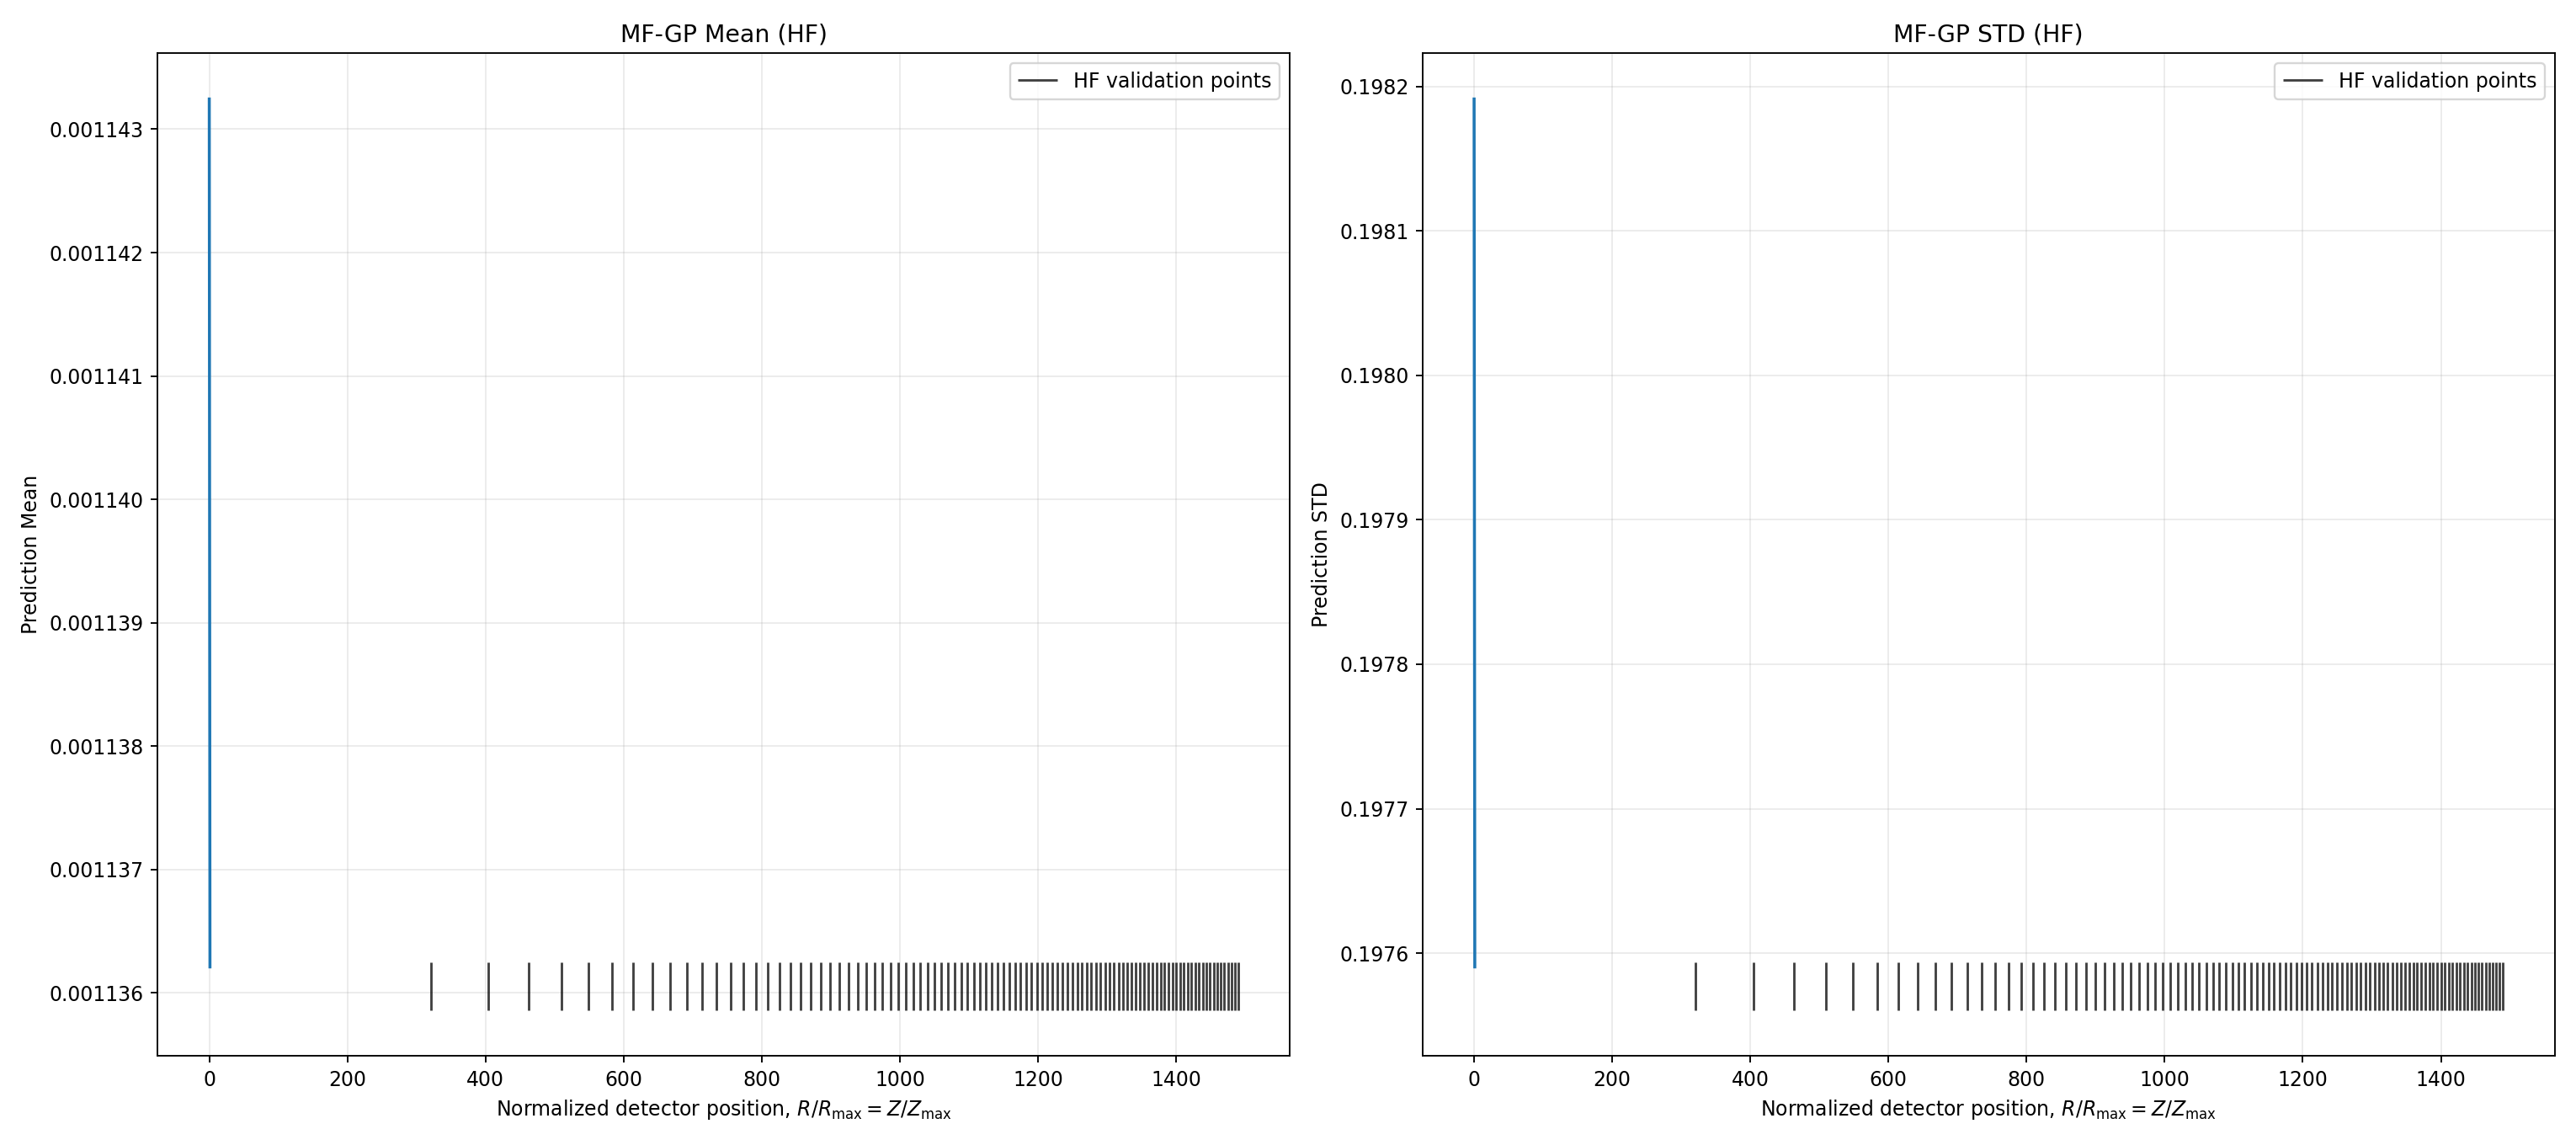

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_linear_mean_std_3d_interactive_iter0.html
Validation 3-sigma: y with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_linear_validation_across_thetas_linear_iter0.png


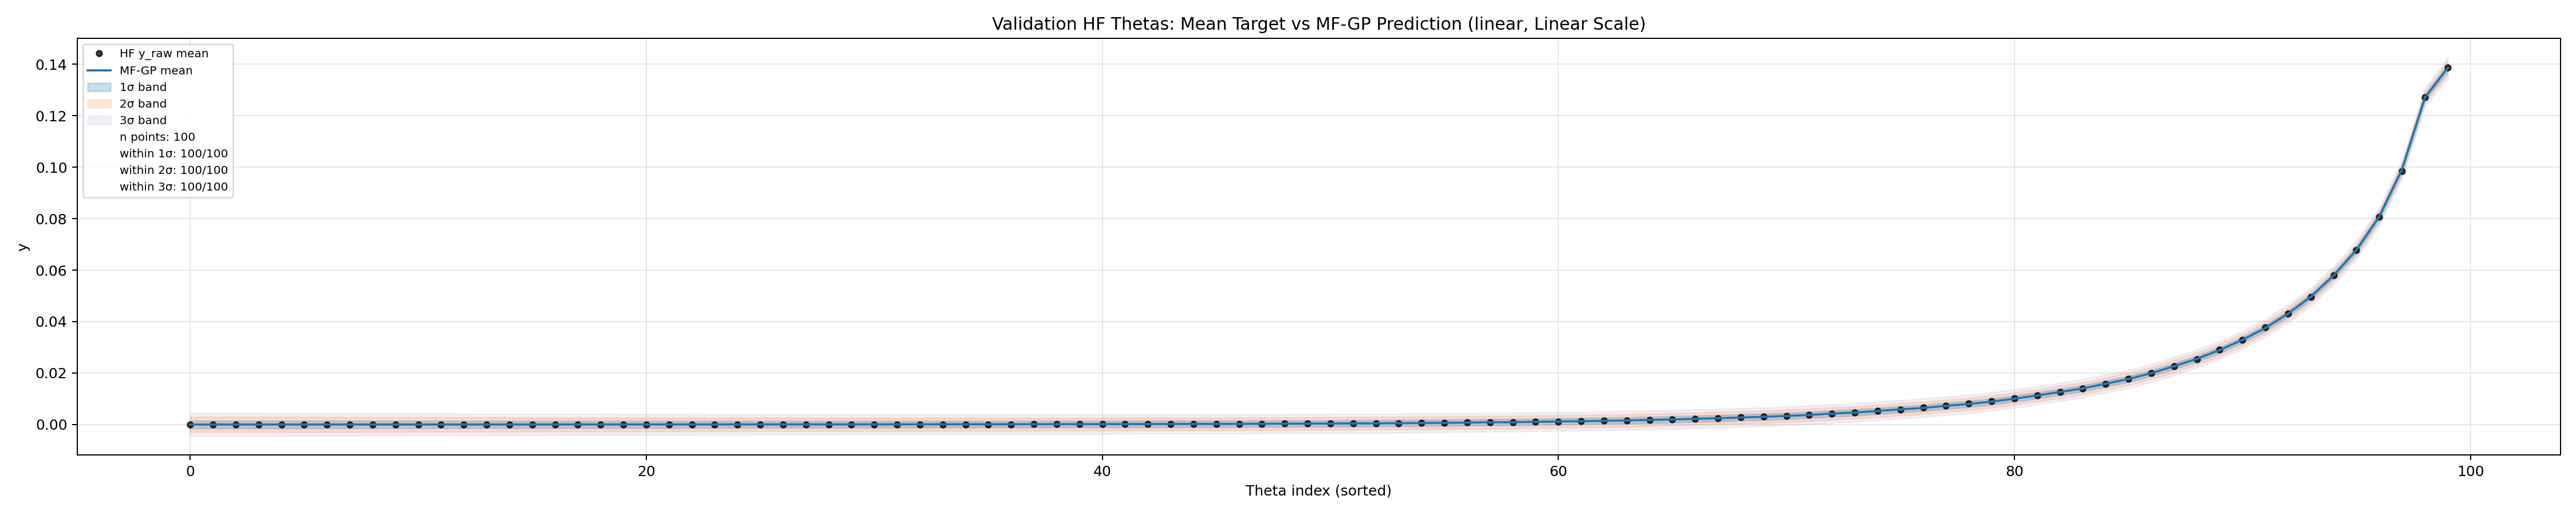

Validation 3-sigma: log10(y) with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_linear_validation_across_thetas_log_linear_sigma_iter0.png


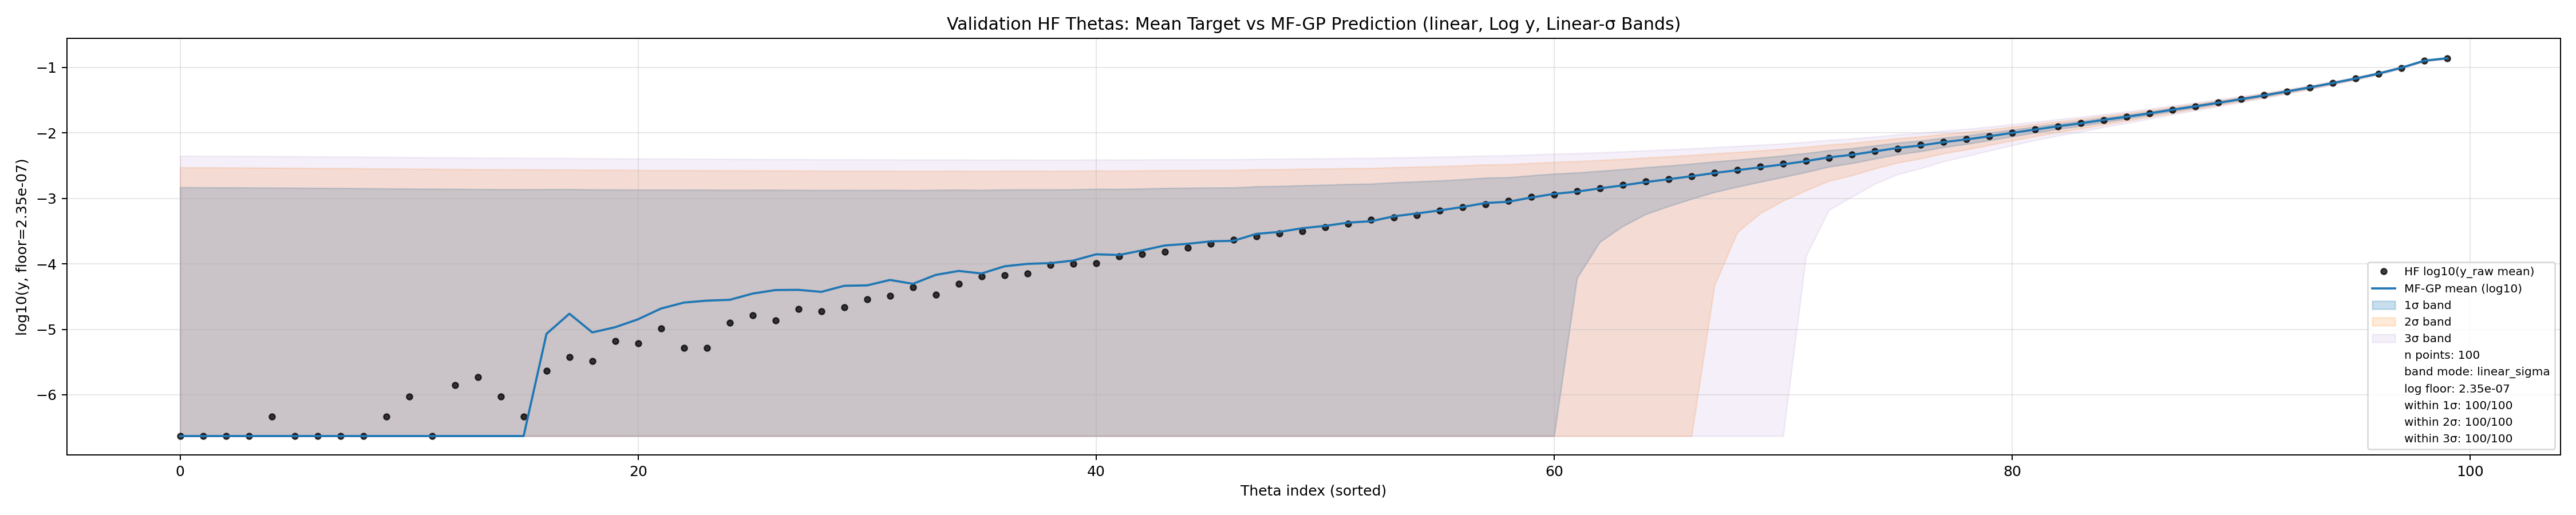

Validation parity: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_linear_validation_parity_linear_iter0.png


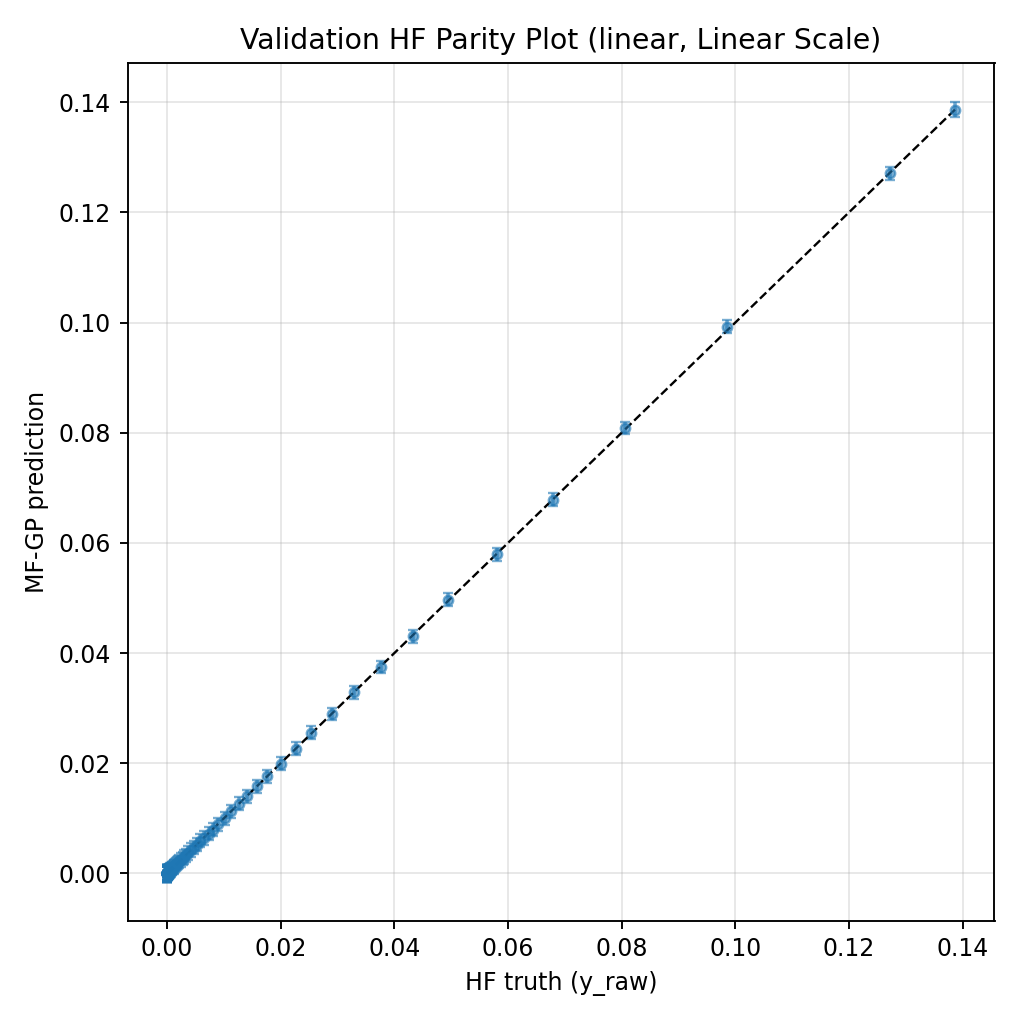

=== Log HF: emulate log10(y_raw) ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_hf_mean_std_iter0.png


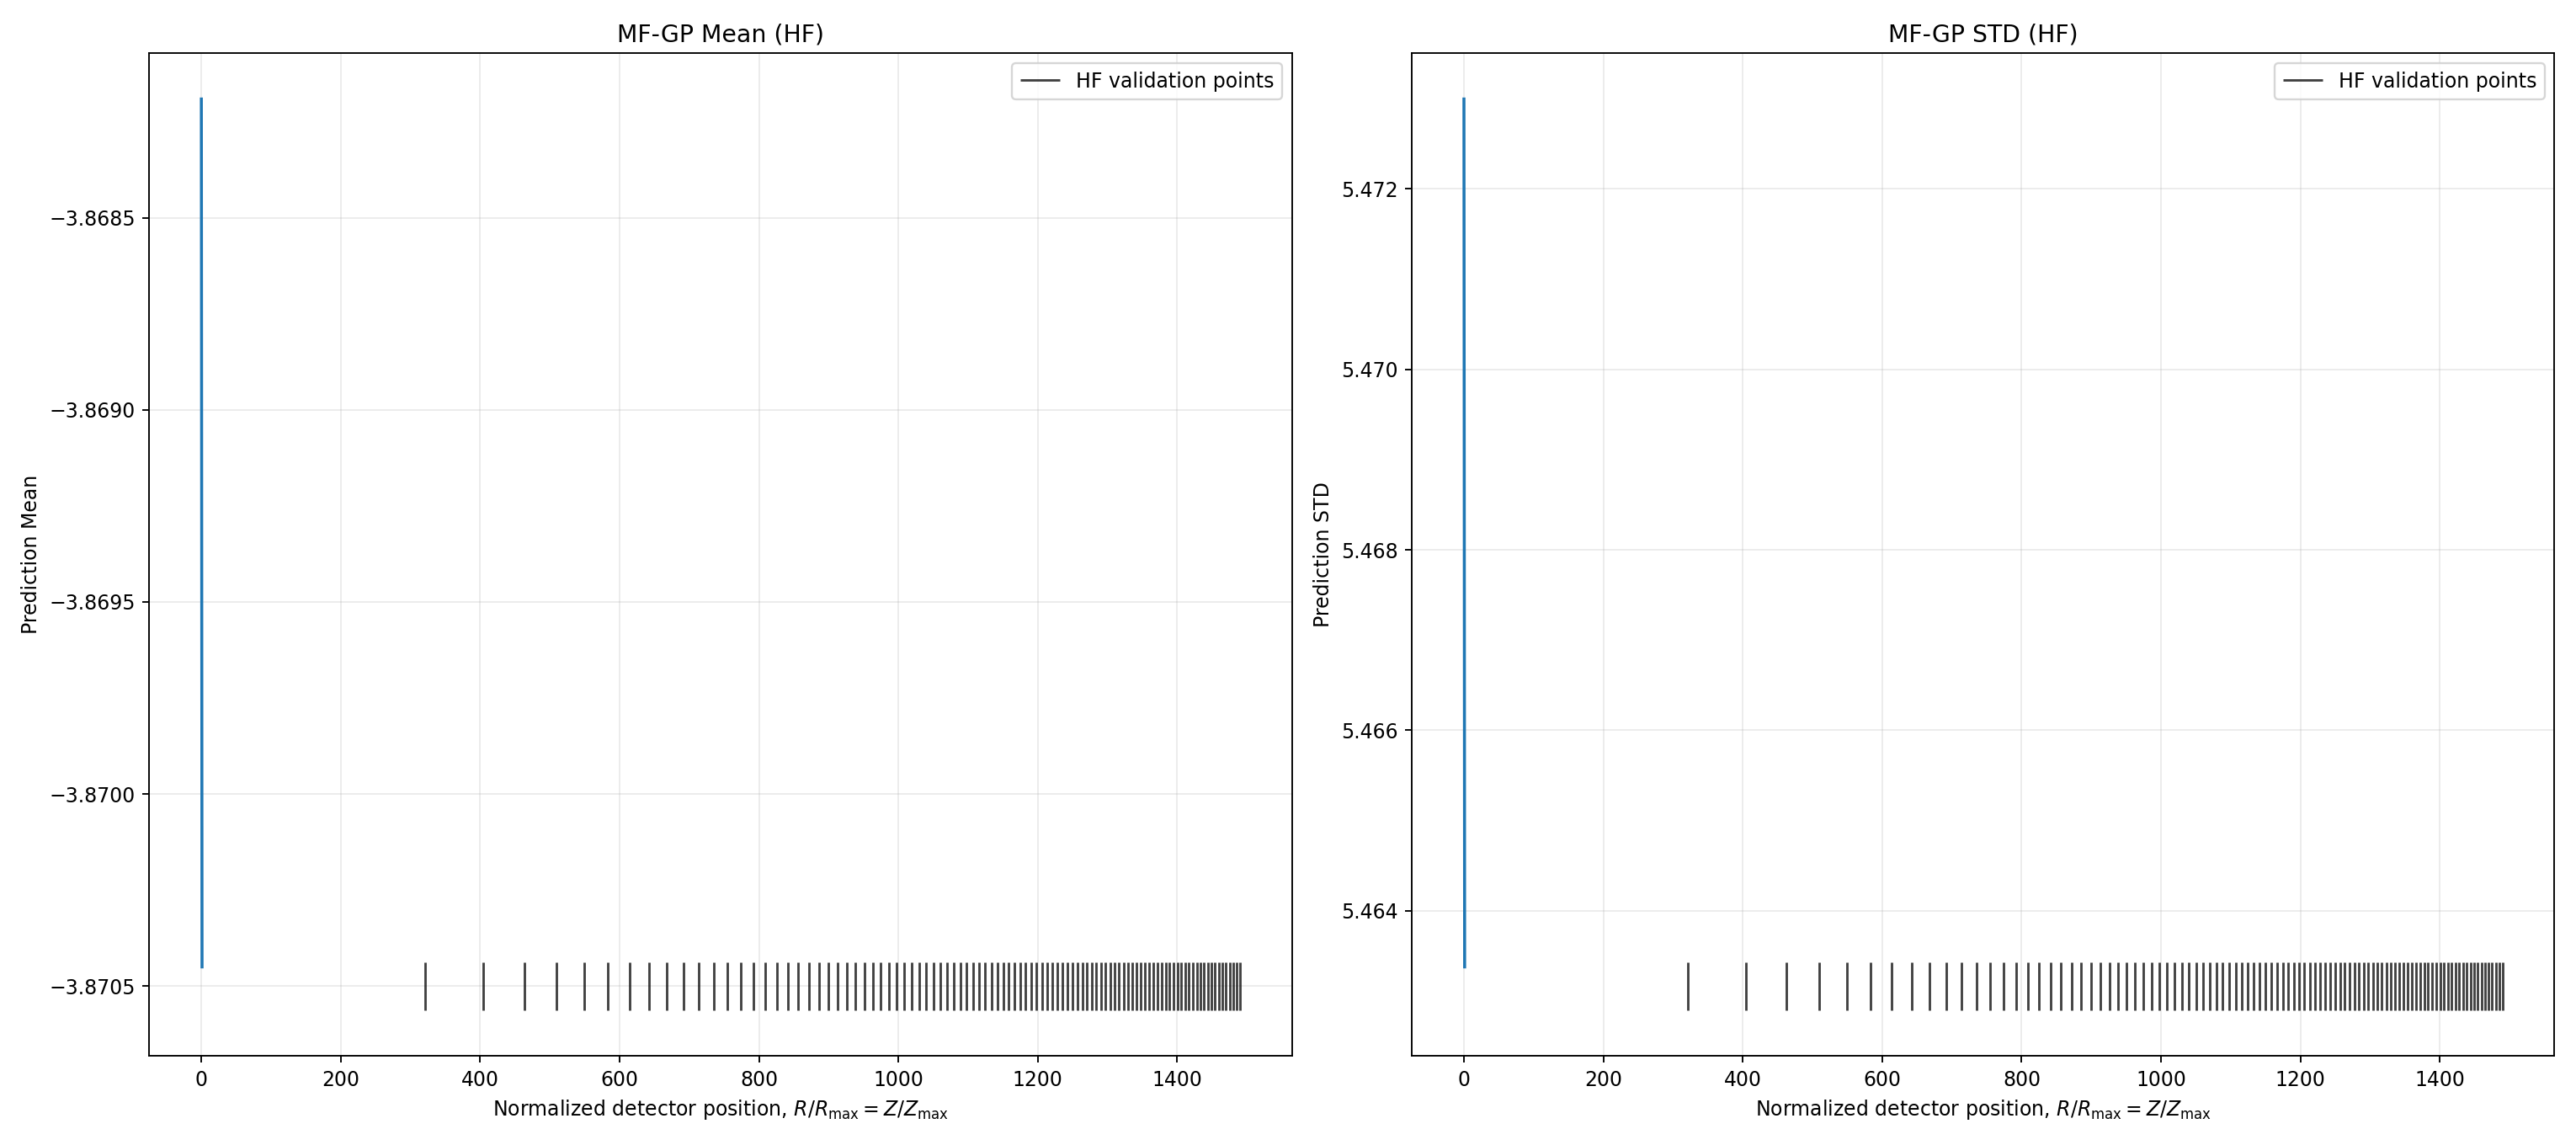

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_hf_mean_std_3d_interactive_iter0.html
Validation 3-sigma: log10 target with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_hf_validation_across_thetas_linear_iter0.png


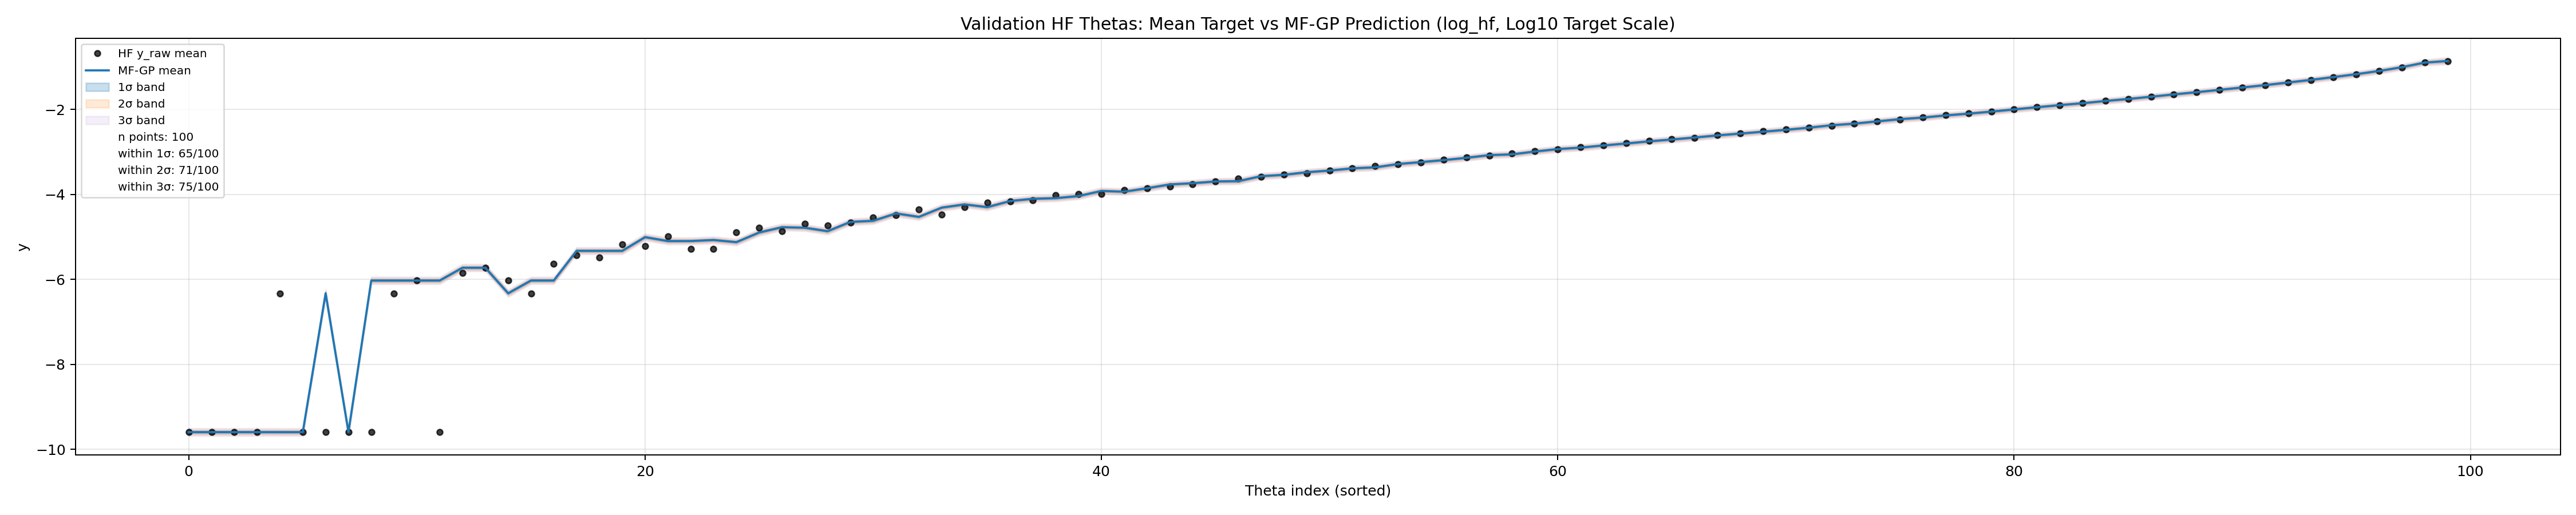

=== Log LF: use log10(y_cnp) ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_lf_mean_std_iter0.png


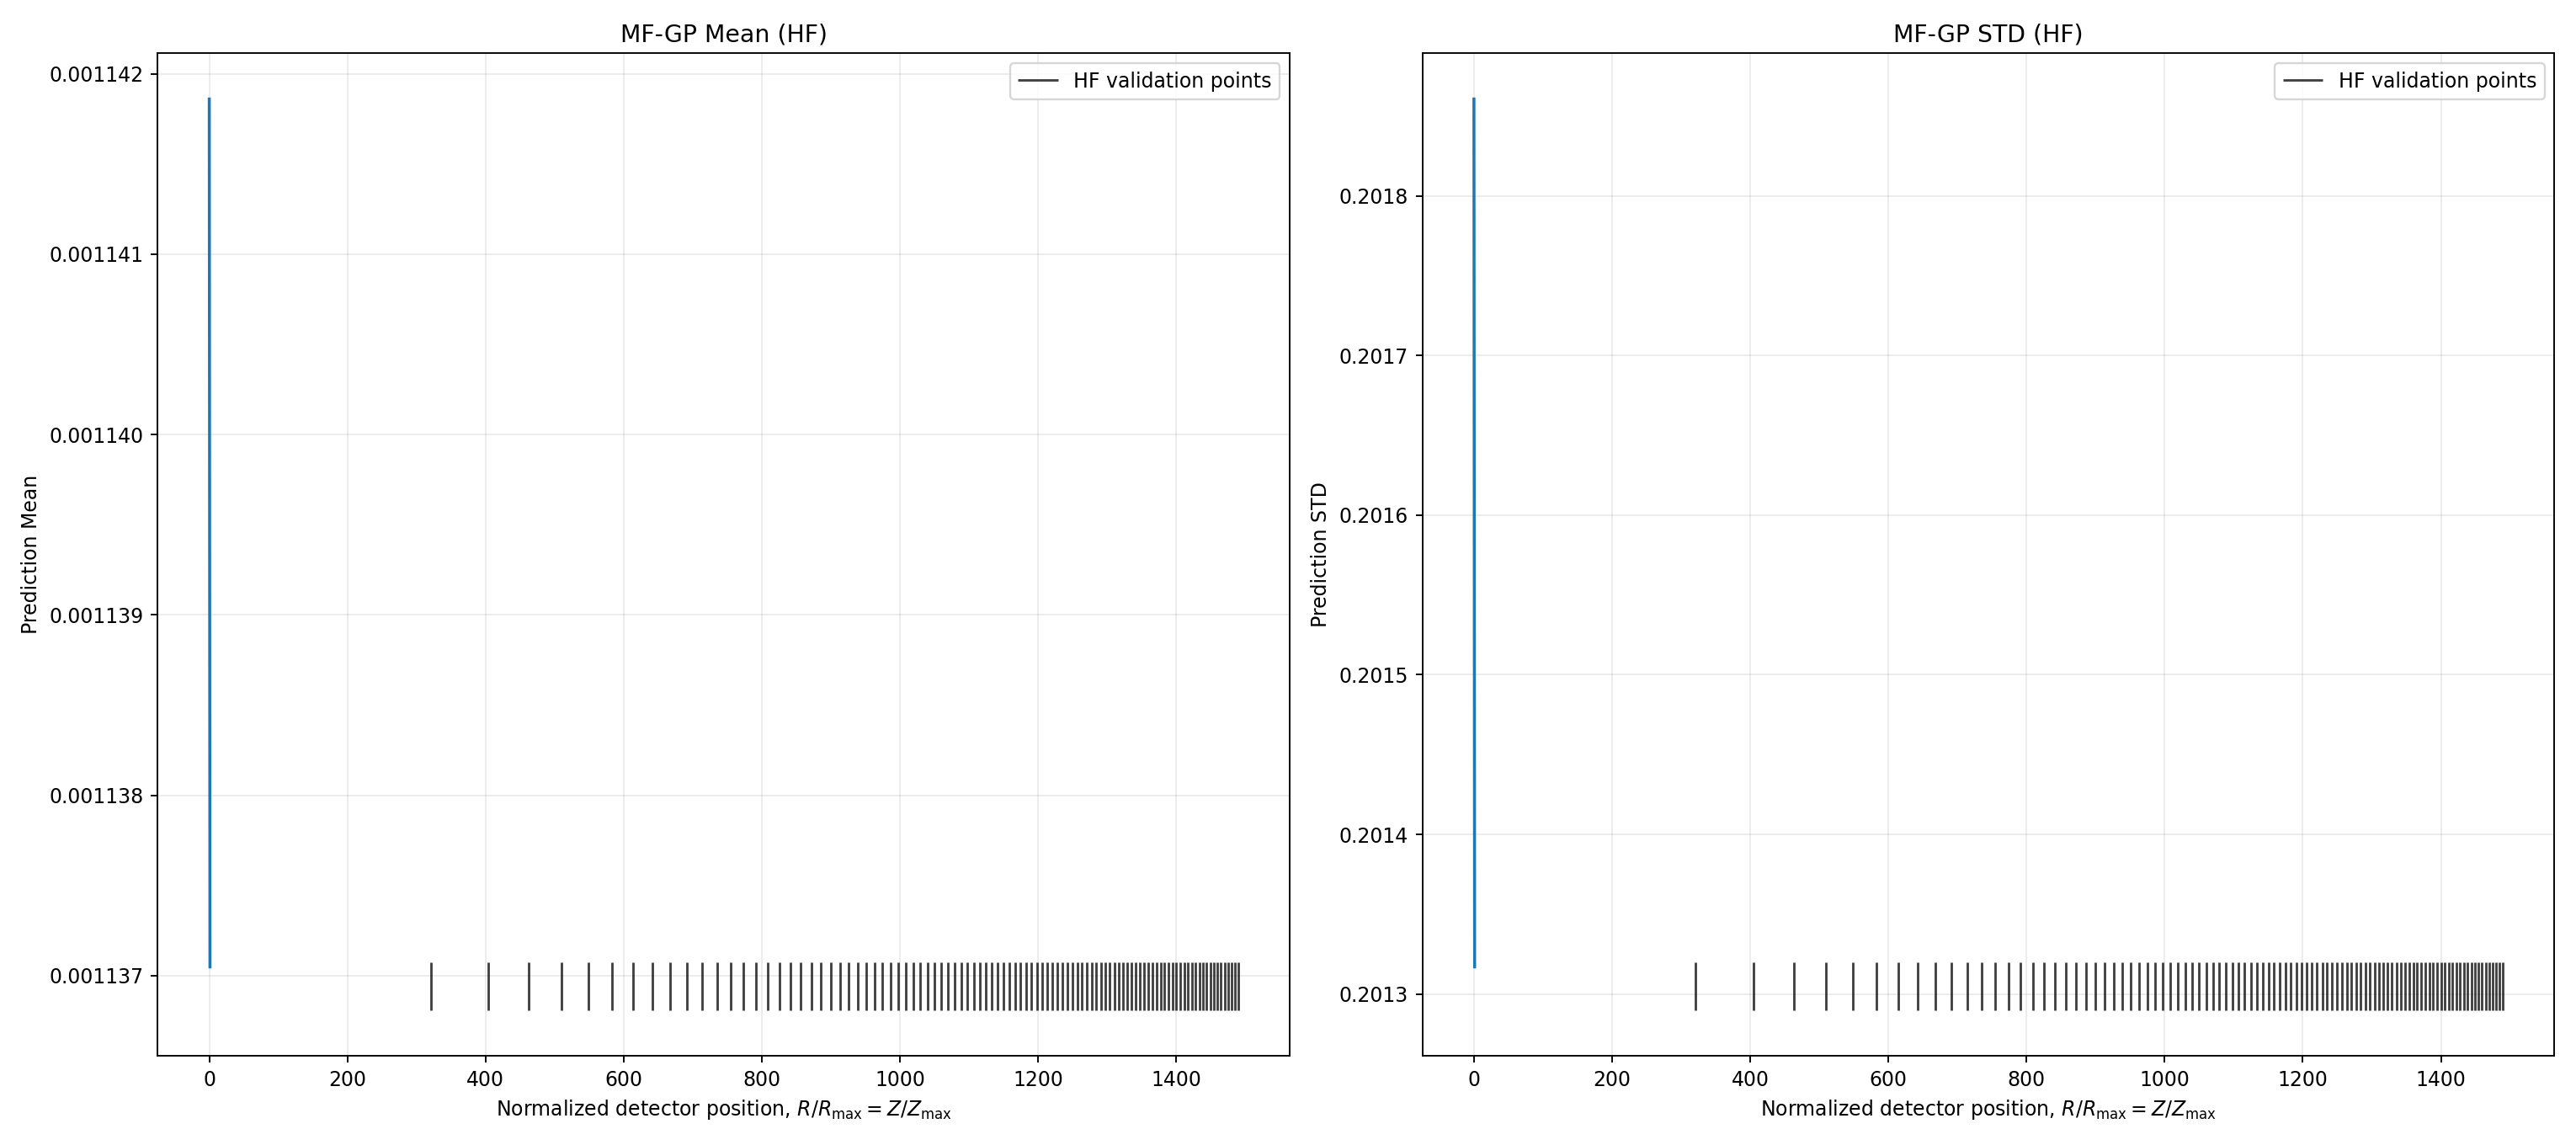

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_lf_mean_std_3d_interactive_iter0.html
Validation 3-sigma: y with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_lf_validation_across_thetas_linear_iter0.png


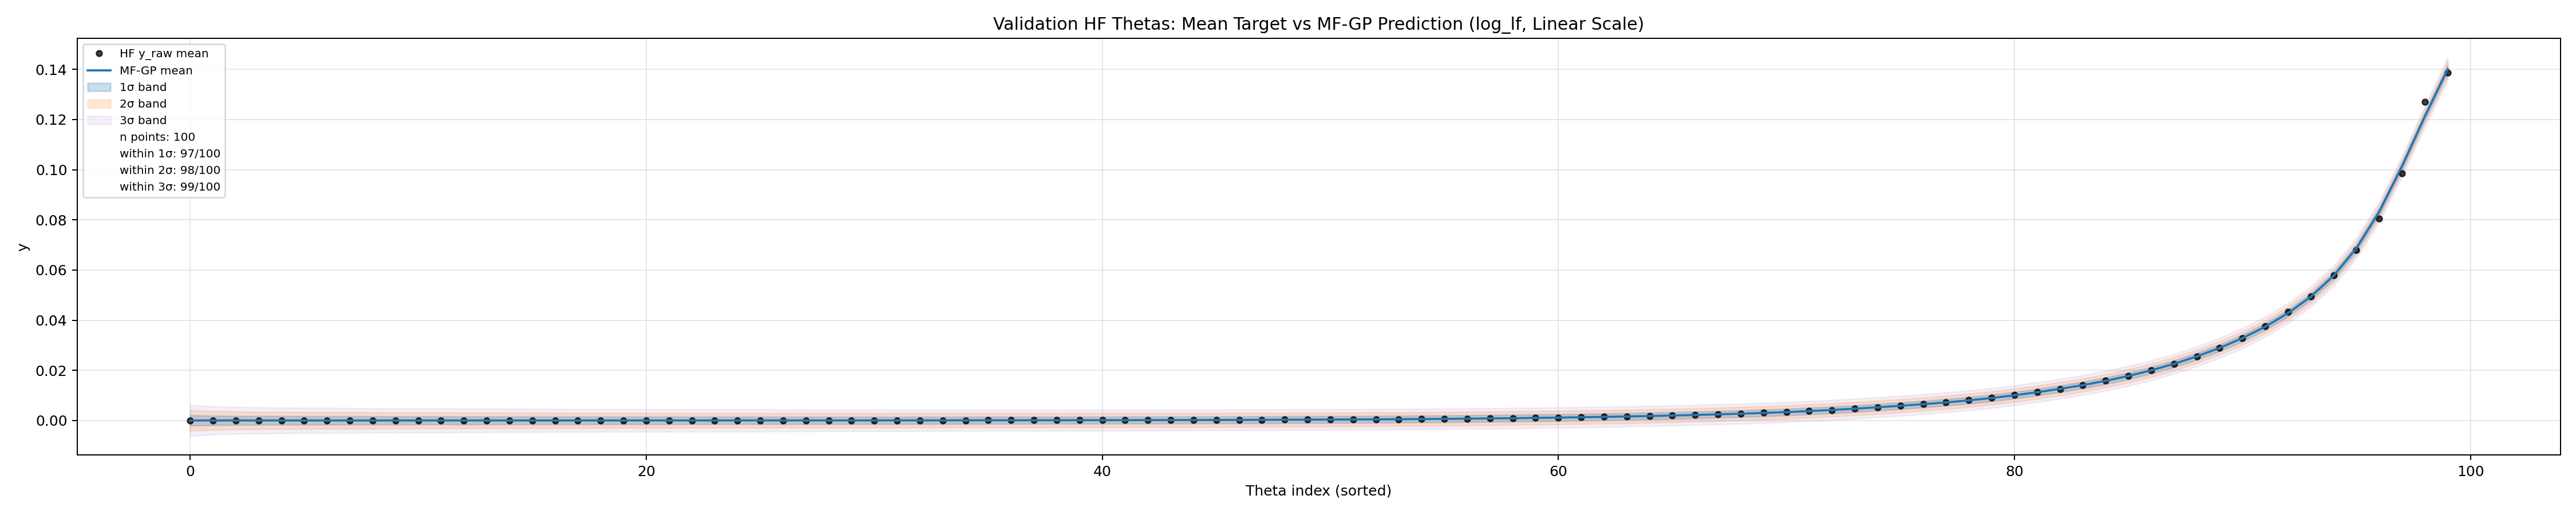

Validation 3-sigma: log10(y) with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_lf_validation_across_thetas_log_linear_sigma_iter0.png


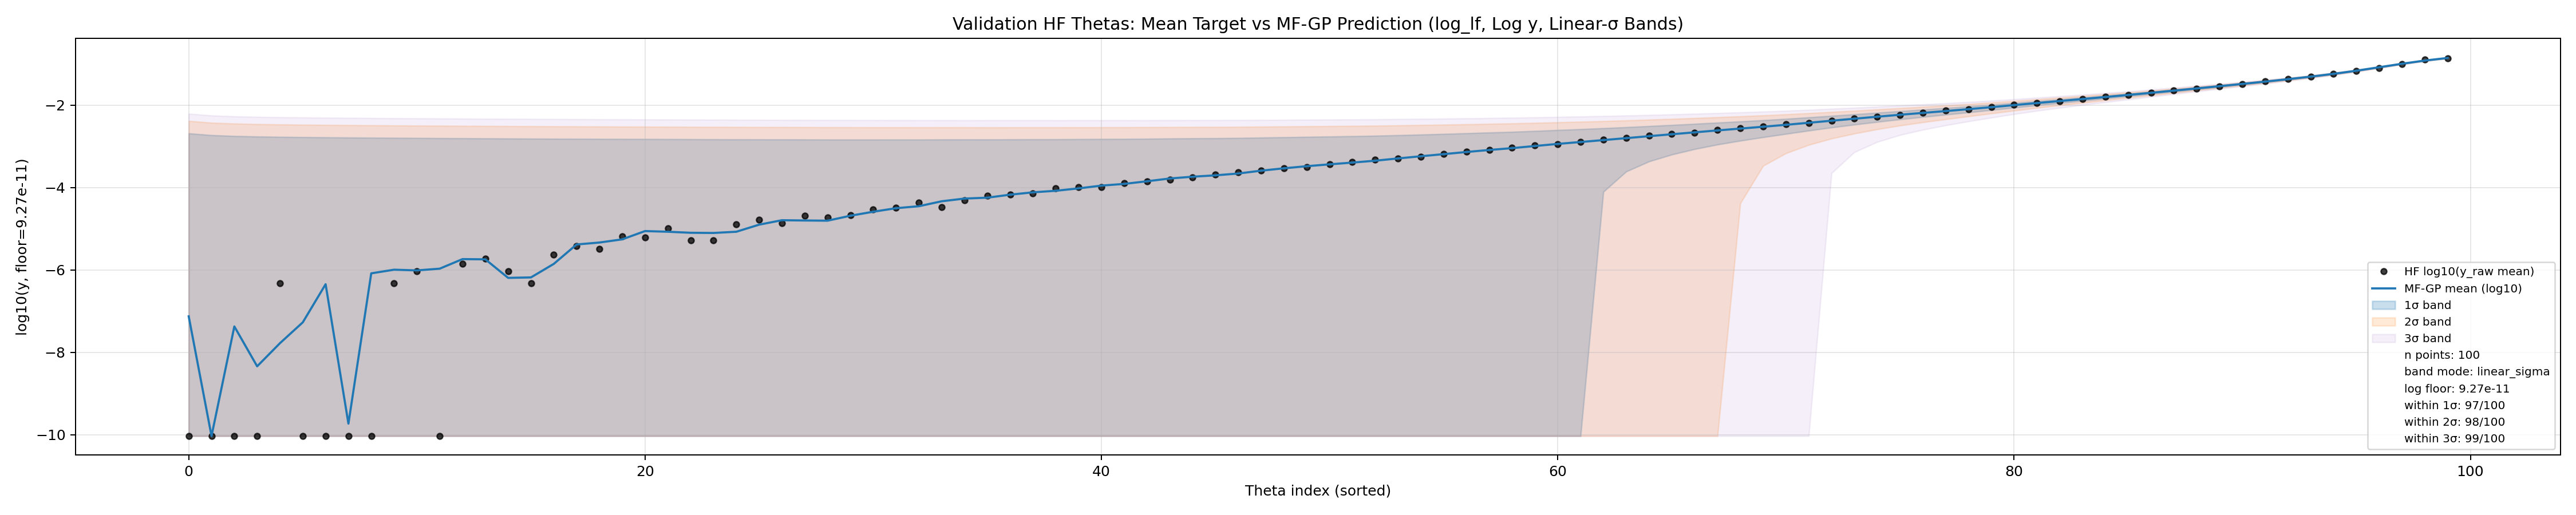

Validation parity: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_lf_validation_parity_linear_iter0.png


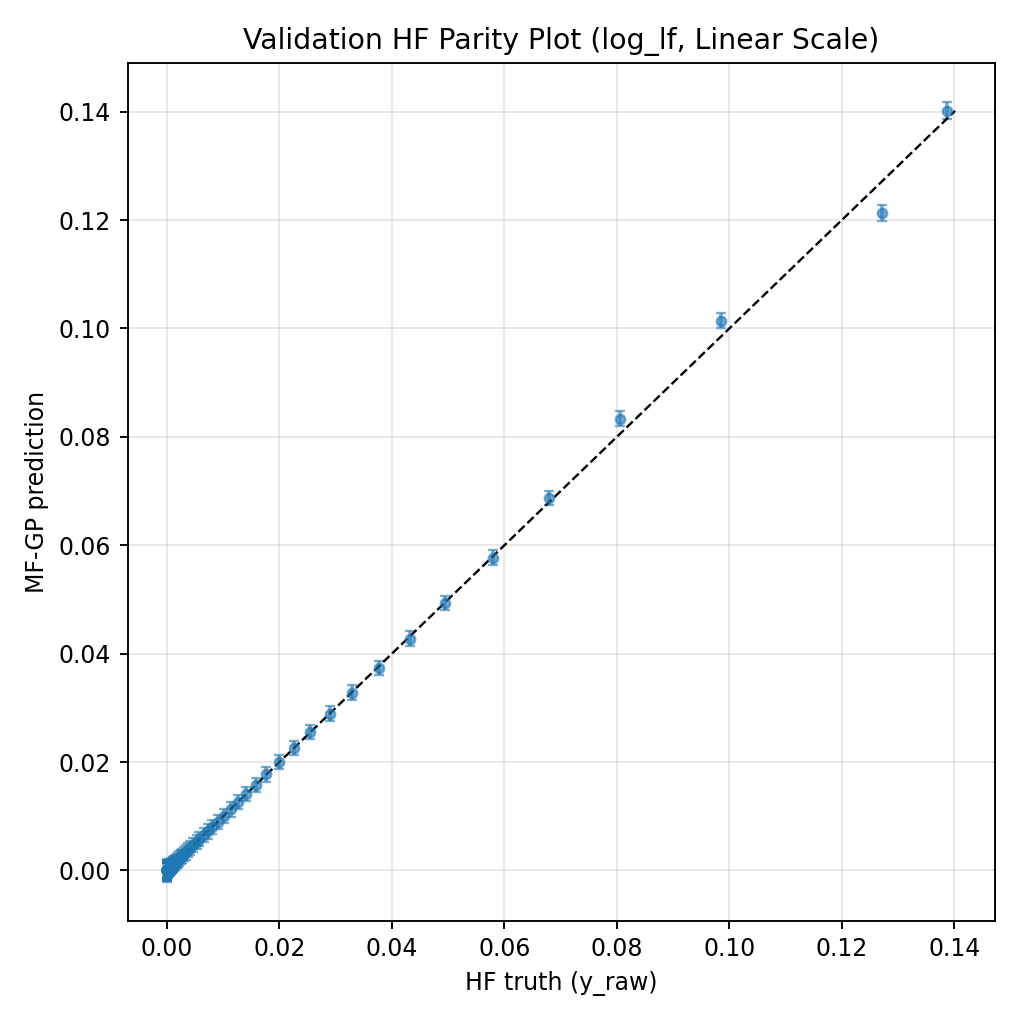

=== Log HF + Log LF: use log10(y_raw) and log10(y_cnp) ===
4-fold MF-GP mean/std: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_both_mean_std_iter0.png


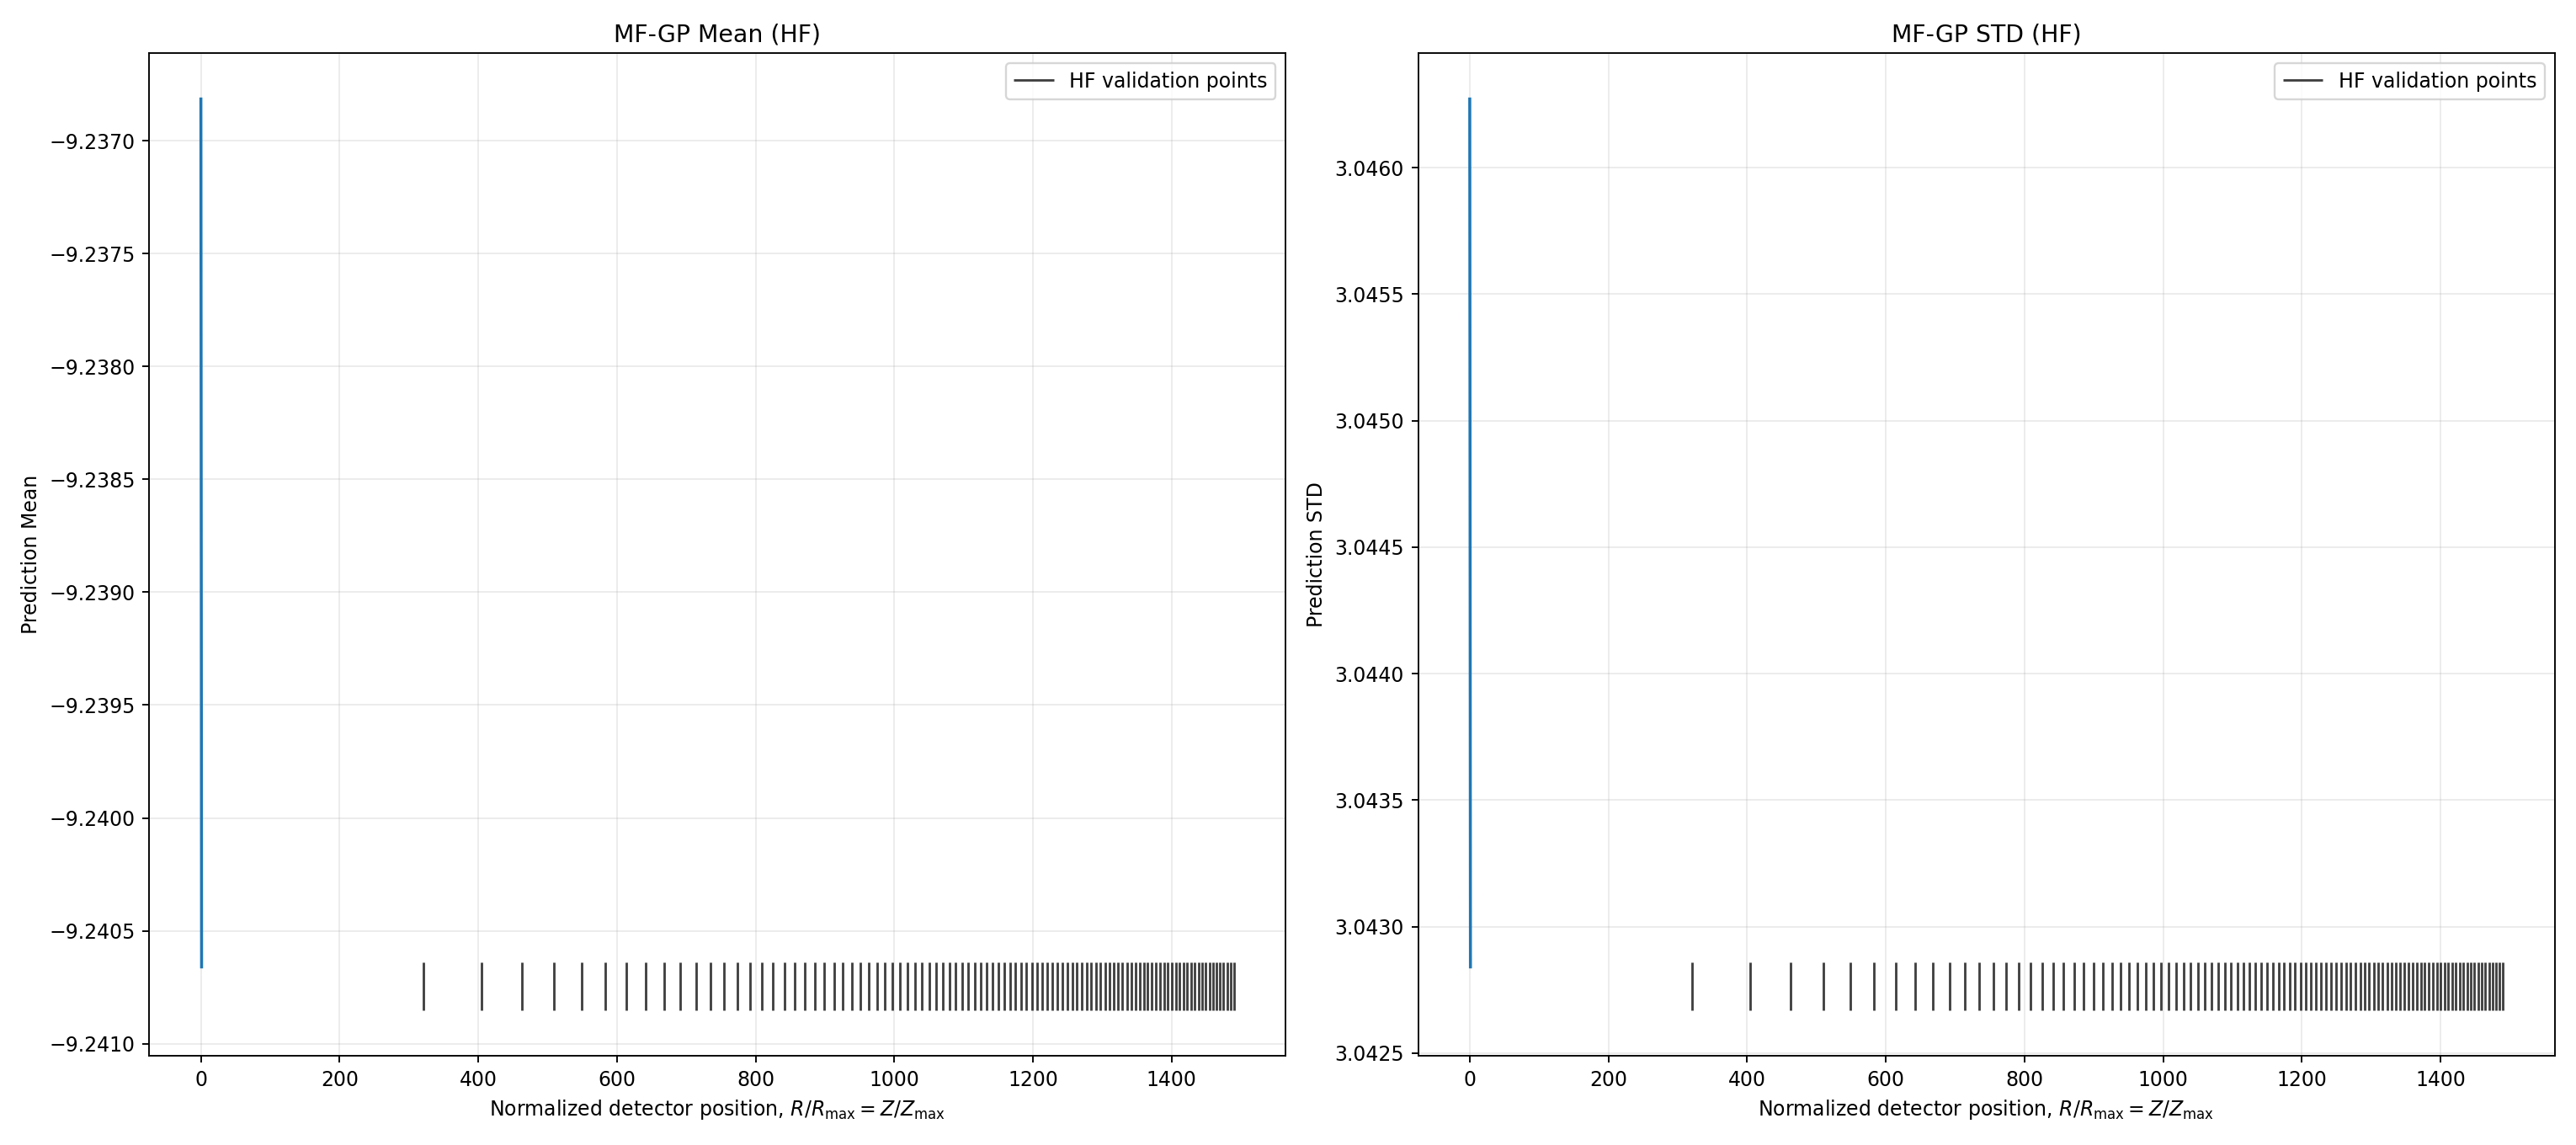

Interactive 3D mean/std HTML: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_both_mean_std_3d_interactive_iter0.html
Validation 3-sigma: log10 target with linear sigma: /home/liuser/pknauss/XLZD/data/out/mfgp/mfgp_xlzd_shell_v1_minibatch_log_both_validation_across_thetas_linear_iter0.png


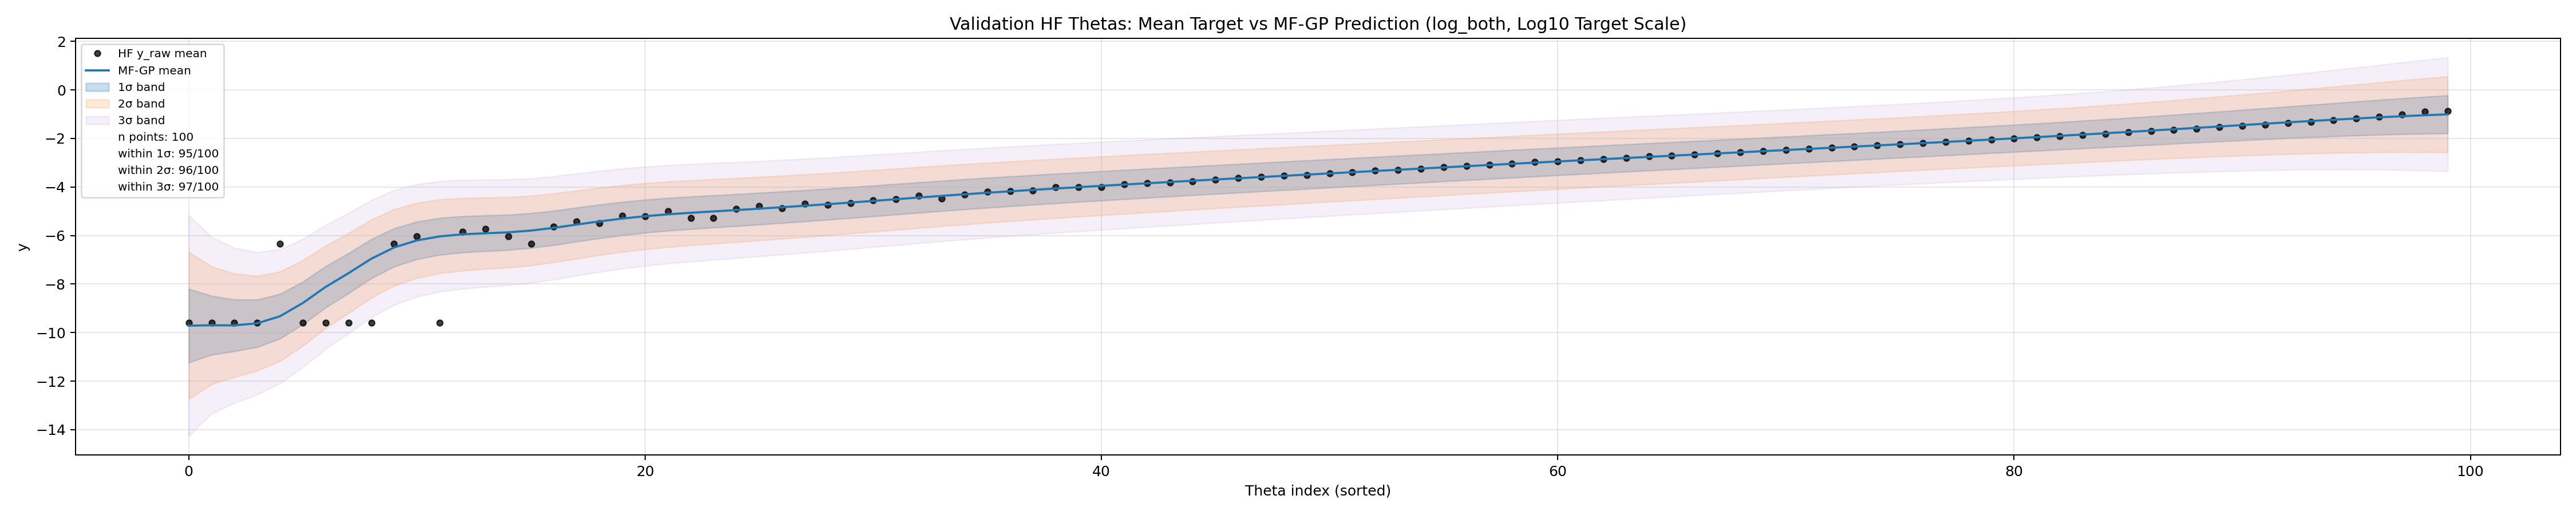

In [9]:
EXPERIMENT_TITLES = {
    "linear": "Normal MF-GP",
    "log_hf": "Log HF: emulate log10(y_raw)",
    "log_lf": "Log LF: use log10(y_cnp)",
    "log_both": "Log HF + Log LF: use log10(y_raw) and log10(y_cnp)",
}

PLOT_SELECTIONS = {
    "linear": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_hf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
    "log_lf": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: y with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: log10(y) with linear sigma", "validation_across_theta_log_linear_sigma_plot"),
        ("Validation parity", "validation_parity_linear_plot"),
    ],
    "log_both": [
        ("4-fold MF-GP mean/std", "mean_std_plot"),
        ("Interactive 3D mean/std HTML", "mean_std_plot_3d_html"),
        ("Validation 3-sigma: log10 target with linear sigma", "validation_across_theta_linear_plot"),
        ("Validation 3-sigma: y with 10**(mu±sigma)", "validation_across_theta_log_plot"),
        ("Validation parity", "validation_parity_log_plot"),
    ],
}

def show_plot(result, label, key):
    value = getattr(result, key, None)
    if not value:
        return
    print(f"{label}: {value}")
    path = Path(value)
    if path.suffix.lower() == ".png" and path.exists():
        try:
            display(Image(filename=str(path)))
        except Exception:
            pass

for transform in TARGET_TRANSFORMS:
    result = mfgp_results.get(transform)
    if result is None:
        continue
    print(f"=== {EXPERIMENT_TITLES[transform]} ===")
    for label, key in PLOT_SELECTIONS[transform]:
        show_plot(result, label, key)
